In [1]:
# 0. Googleドライブのマウント
from google.colab import drive
drive.mount('/content/drive')

import json
import numpy as np

file_path = '/content/drive/MyDrive/qwen_sft_dialogues.jsonl'

total_threads = 0
turn_counts = []
user_chars_total = 0
assistant_chars_total = 0

print("Phase 0.5: SFTコーパスの統計解析を開始します...")

with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        messages = data.get("messages", [])

        total_threads += 1
        turn_counts.append(len(messages))

        for msg in messages:
            role = msg.get("role")
            content_len = len(msg.get("content", ""))

            if role == "user":
                user_chars_total += content_len
            elif role == "assistant":
                assistant_chars_total += content_len

# 統計量の計算
avg_turns = np.mean(turn_counts)
max_turns = np.max(turn_counts)
min_turns = np.min(turn_counts)

print("="*40)
print(f"【コーパス統計情報】")
print(f"総スレッド数 (Total Threads): {total_threads}")
print(f"総ターン数 (Total Turns)    : {sum(turn_counts)}")
print(f"平均ターン/スレッド         : {avg_turns:.2f}")
print(f"最大ターン/スレッド         : {max_turns}")
print(f"最小ターン/スレッド         : {min_turns}")
print("-" * 40)
print(f"User総文字数                : {user_chars_total:,}")
print(f"Assistant総文字数           : {assistant_chars_total:,}")
if user_chars_total > 0:
    print(f"A/U 文字数比率              : {assistant_chars_total / user_chars_total:.2f}")
print("="*40)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Phase 0.5: SFTコーパスの統計解析を開始します...
【コーパス統計情報】
総スレッド数 (Total Threads): 1654
総ターン数 (Total Turns)    : 165280
平均ターン/スレッド         : 99.93
最大ターン/スレッド         : 2601
最小ターン/スレッド         : 2
----------------------------------------
User総文字数                : 20,227,518
Assistant総文字数           : 77,356,744
A/U 文字数比率              : 3.82


/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

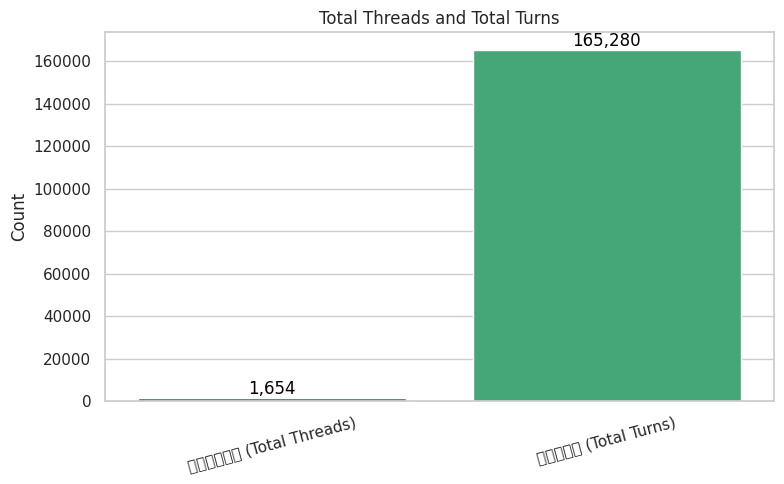

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
display(stats_df.head())

NameError: name 'stats_df' is not defined

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

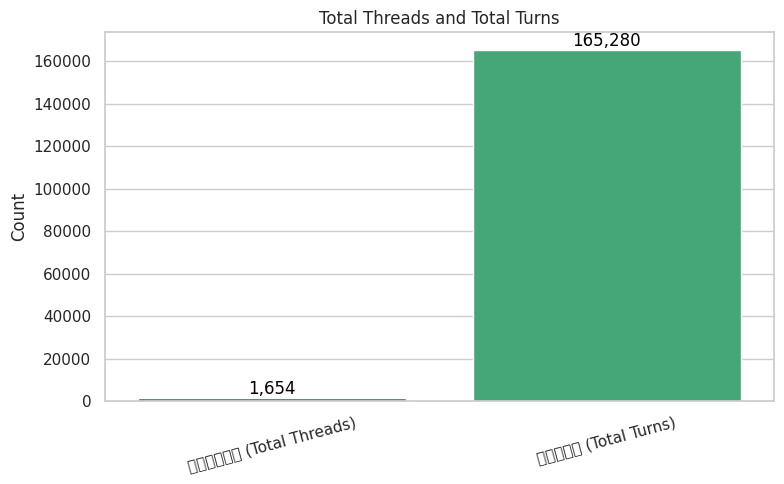

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

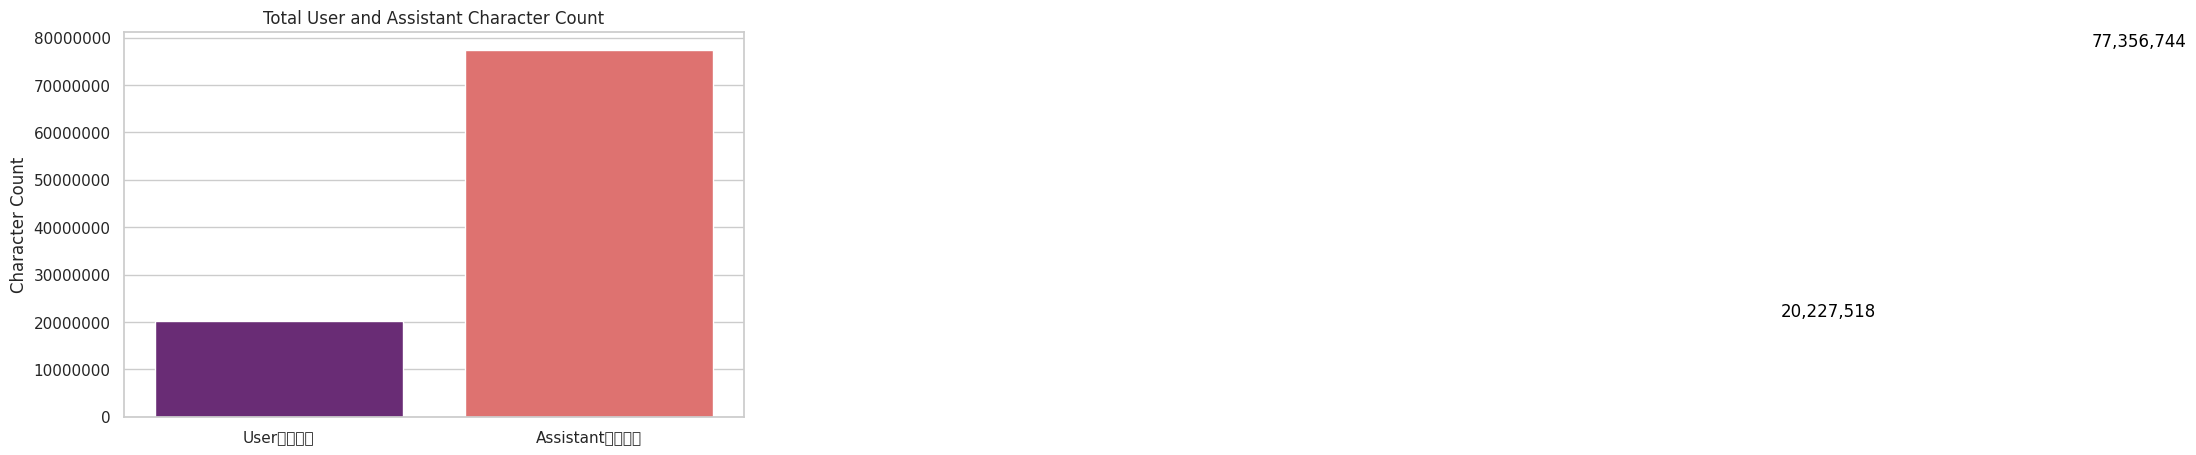

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

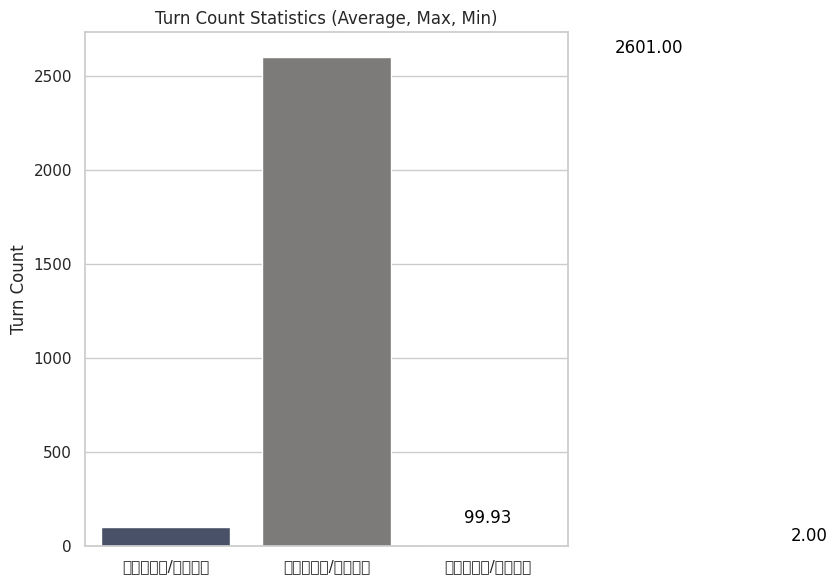

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


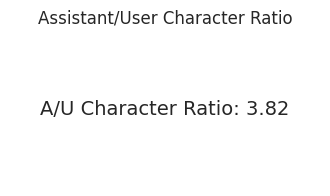

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

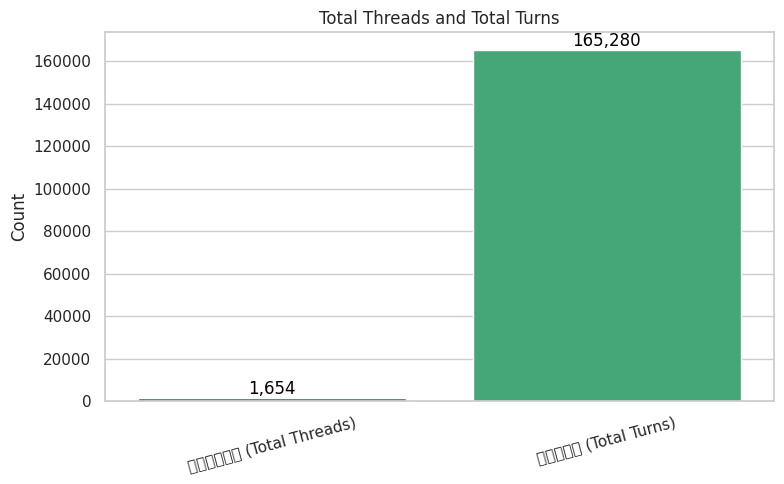

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

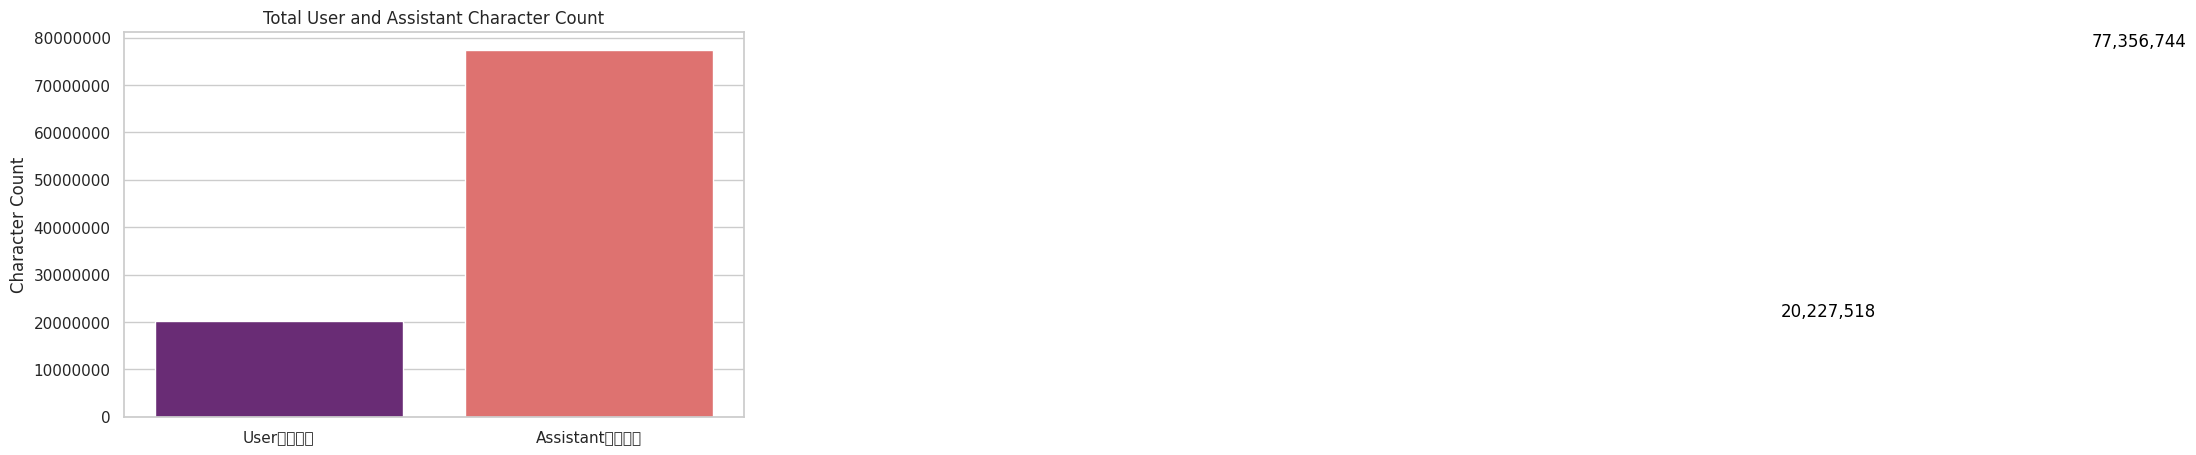

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

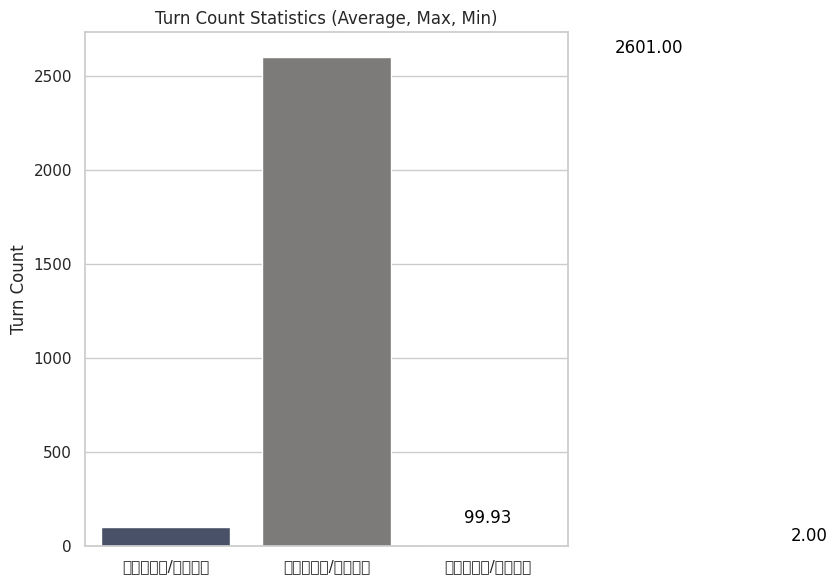

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


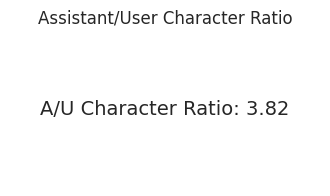

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

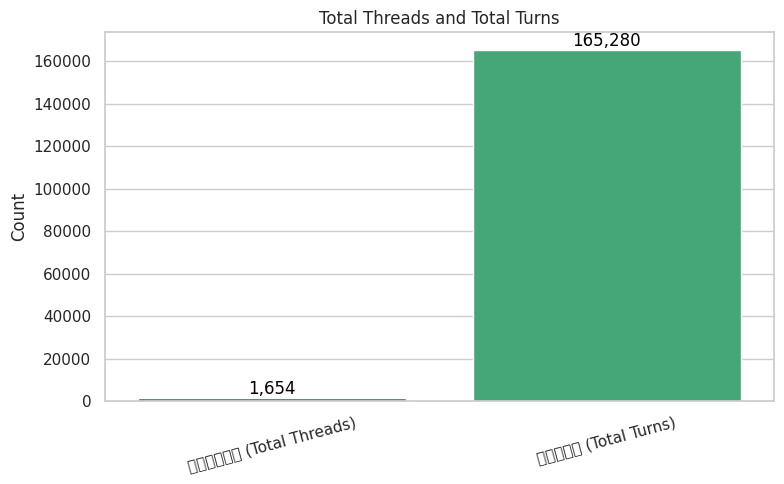

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

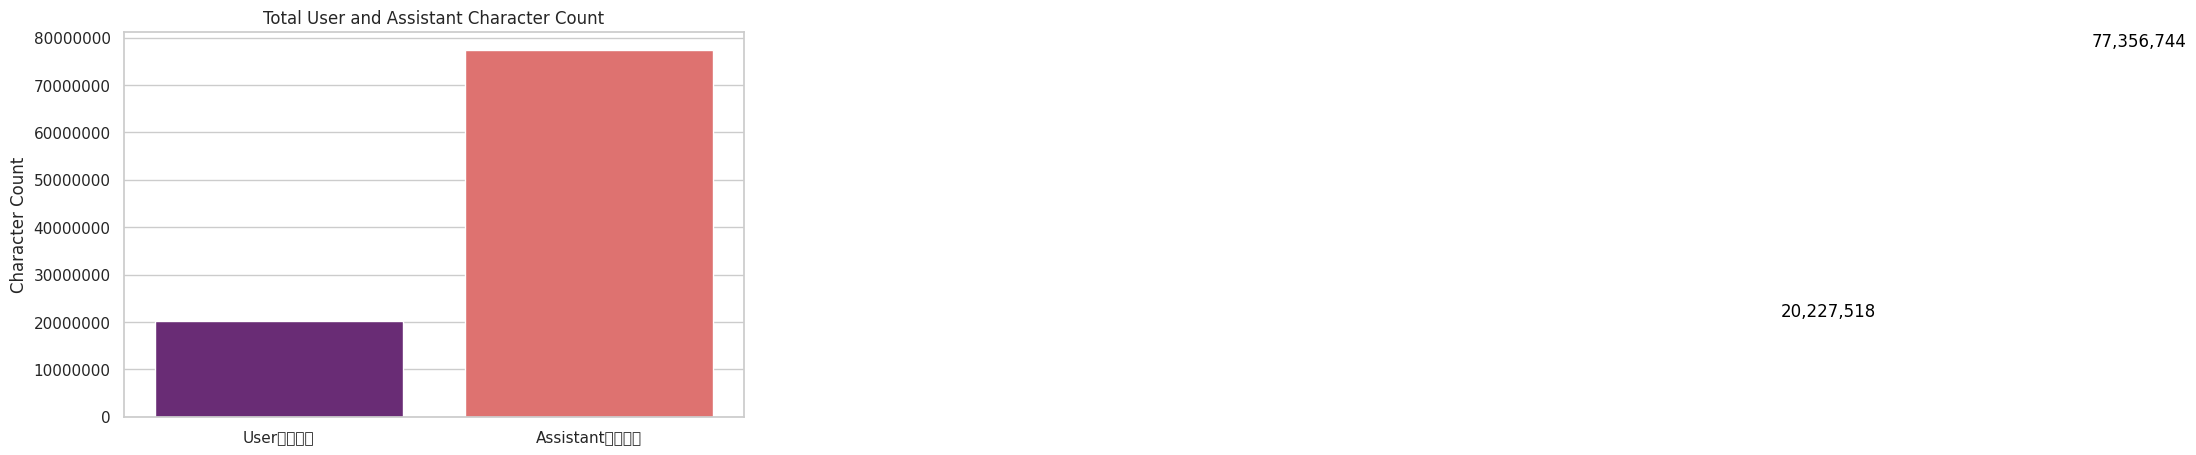

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

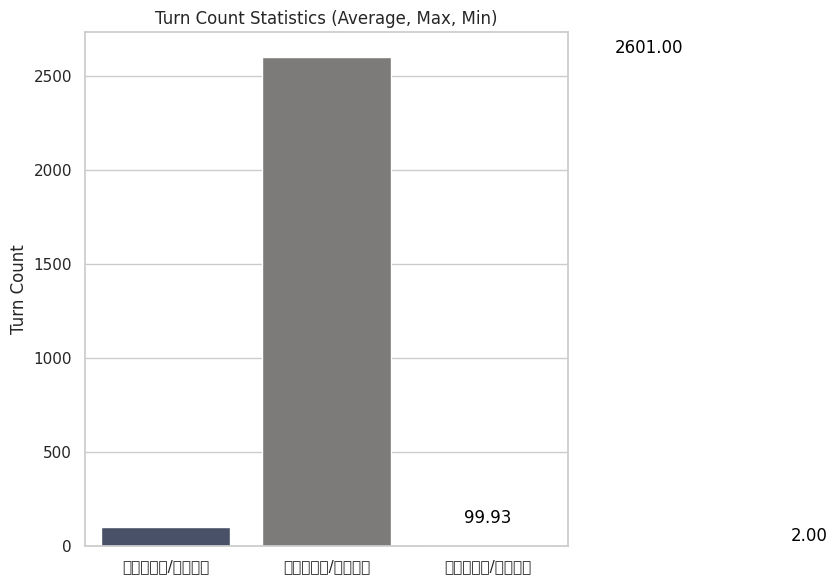

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


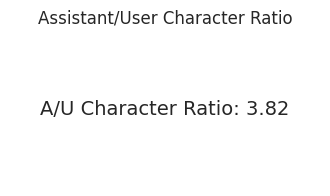

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

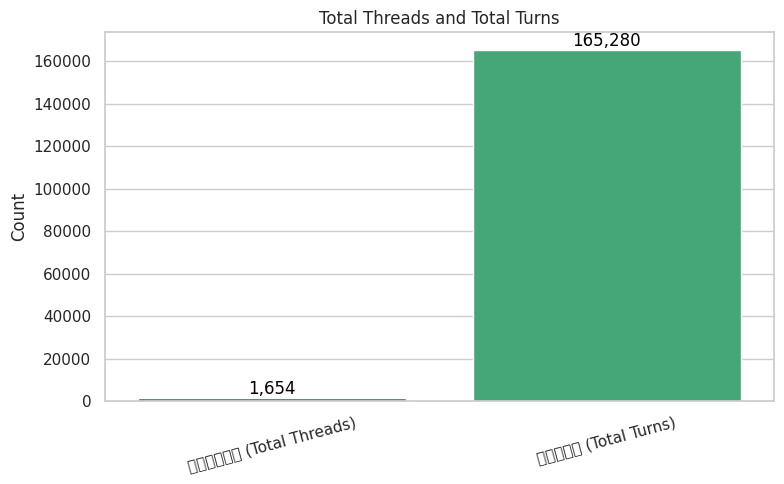

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

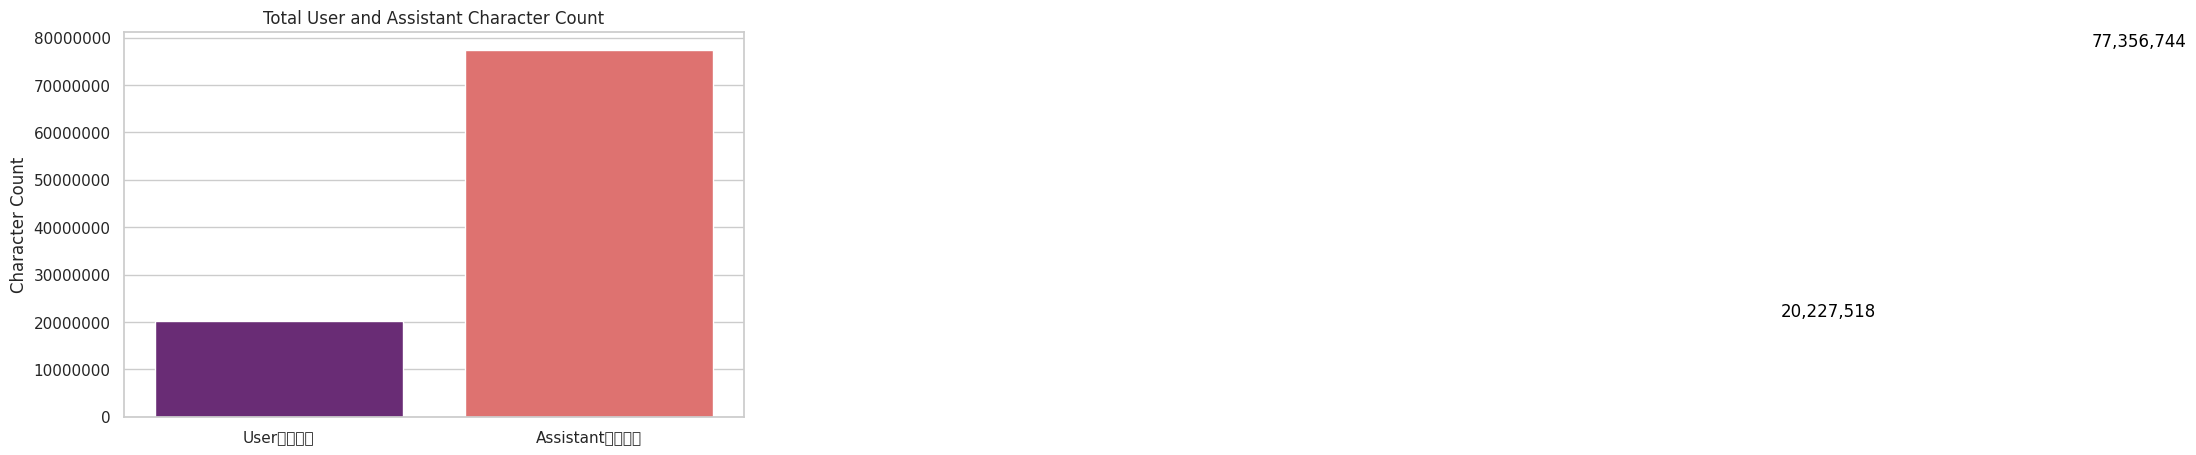

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

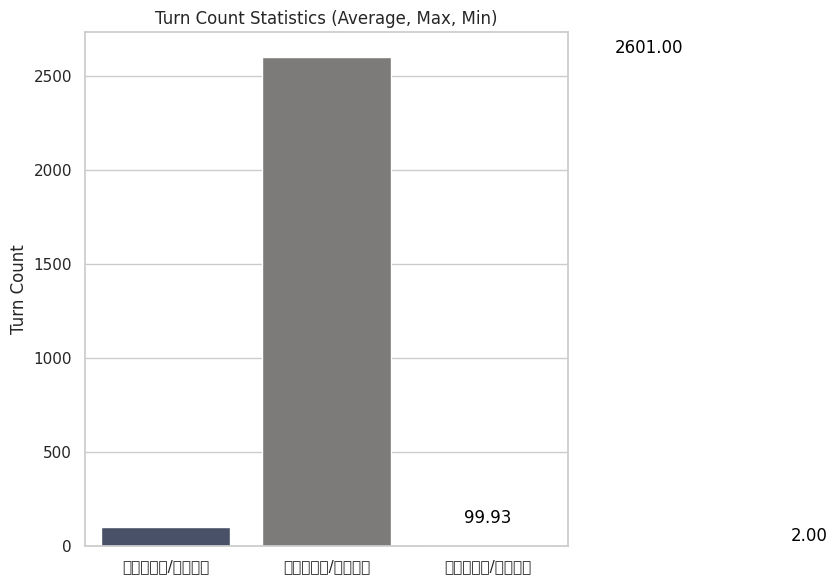

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


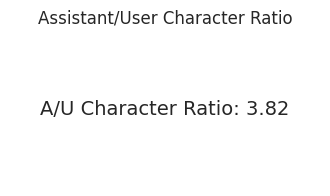

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

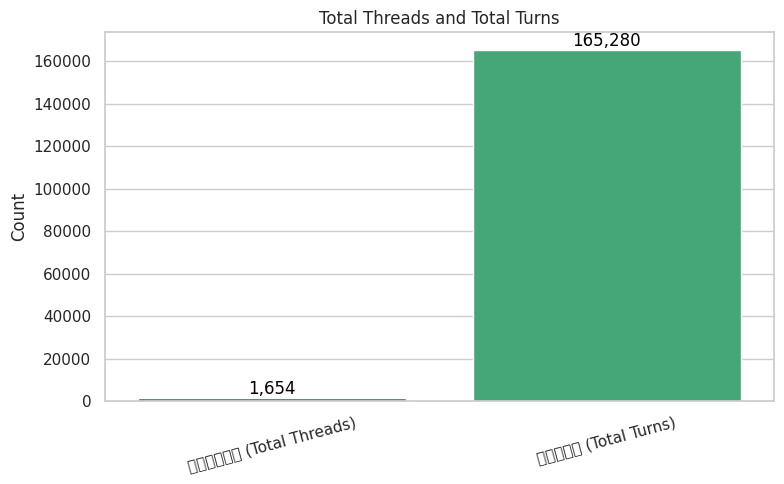

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

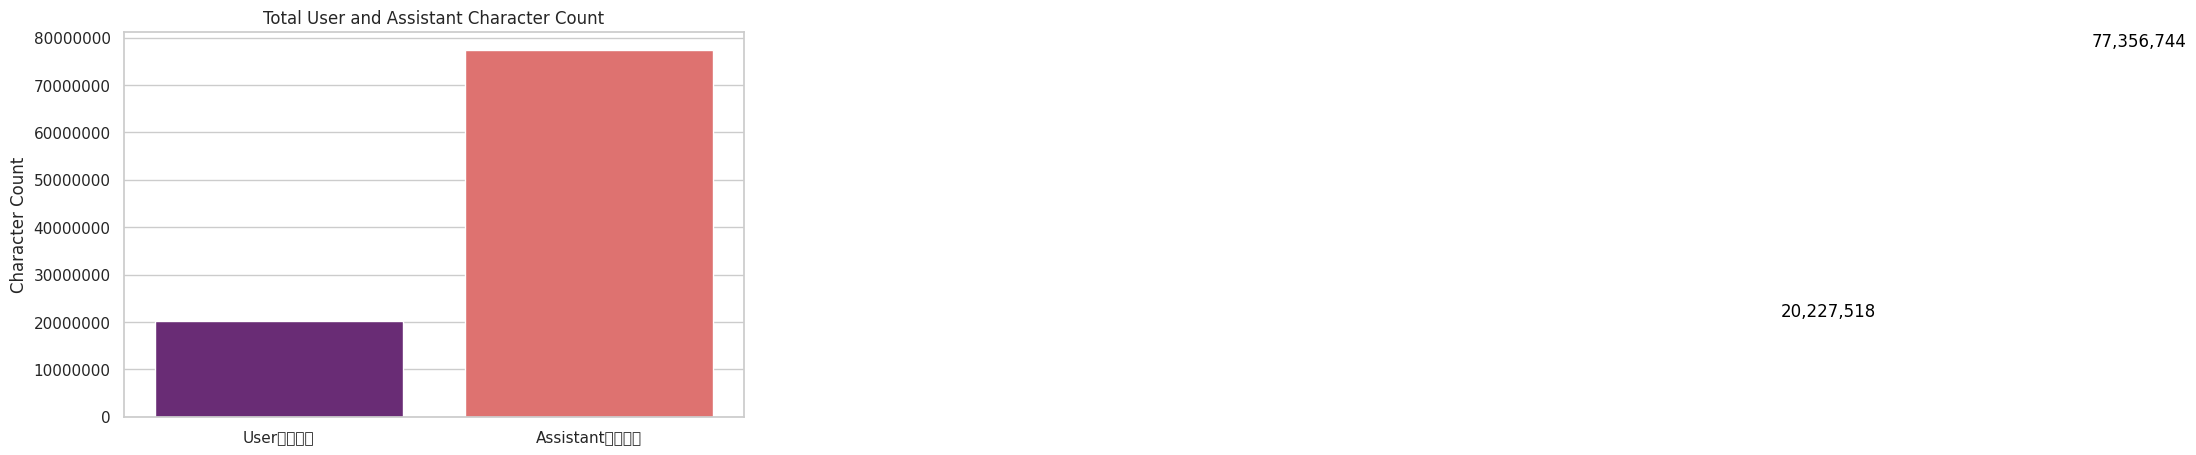

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

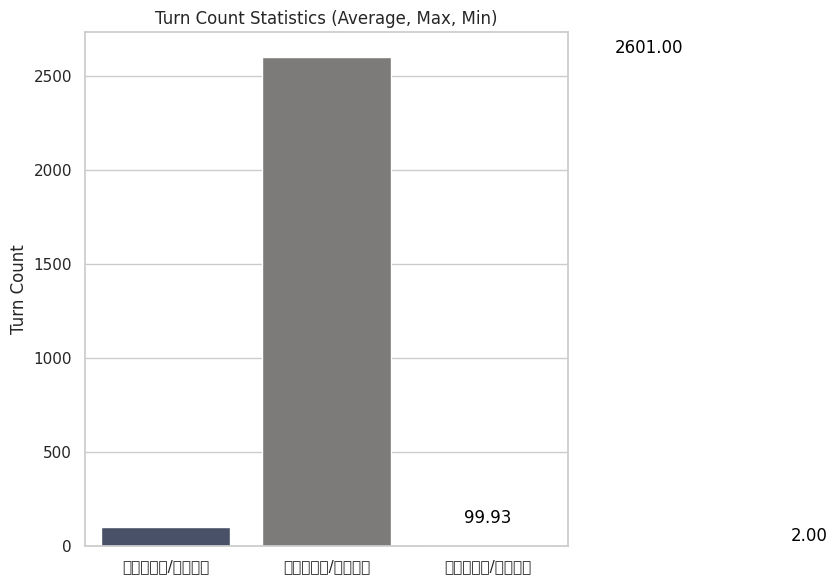

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


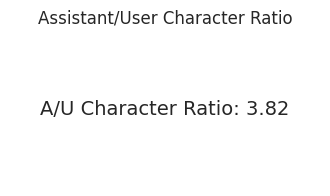

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

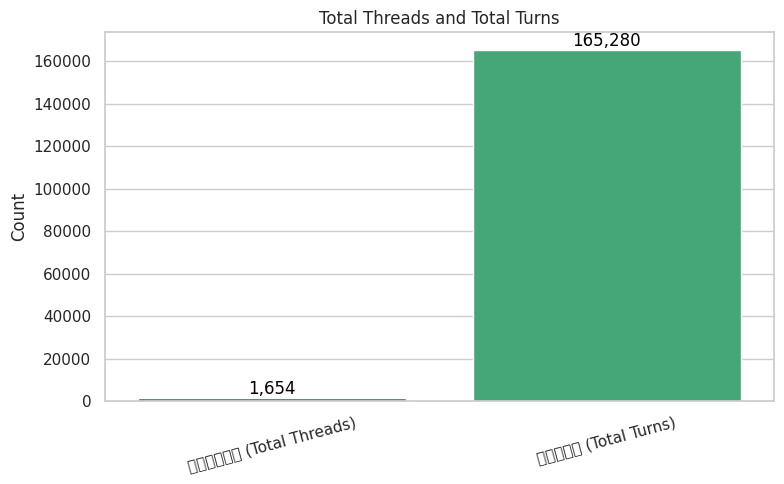

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

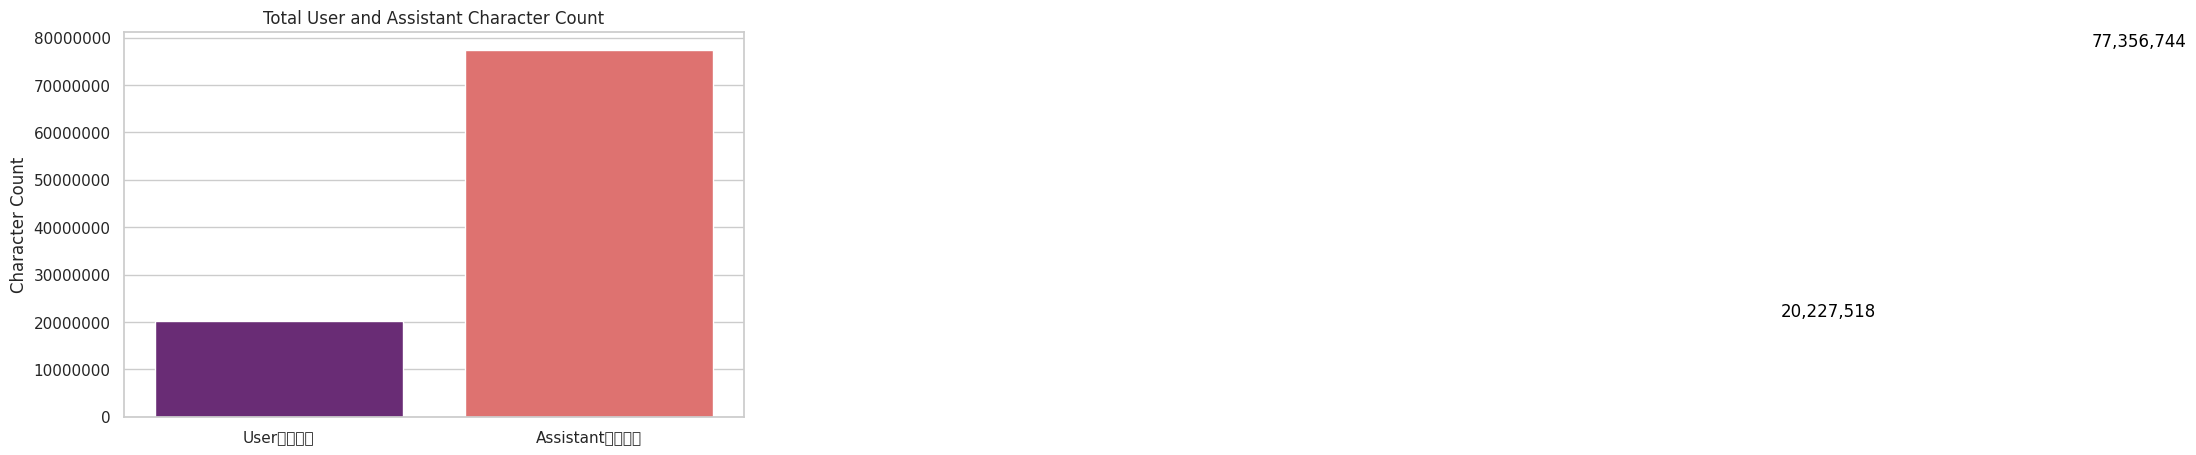

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

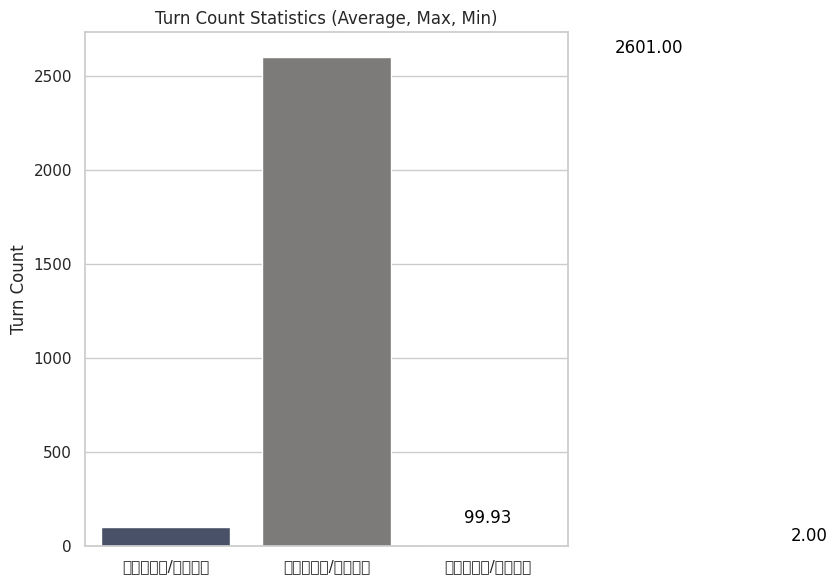

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


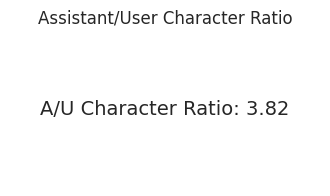

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

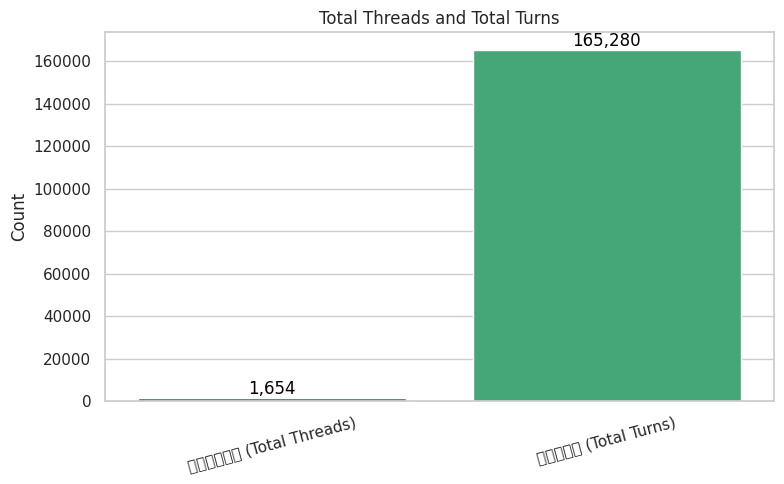

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

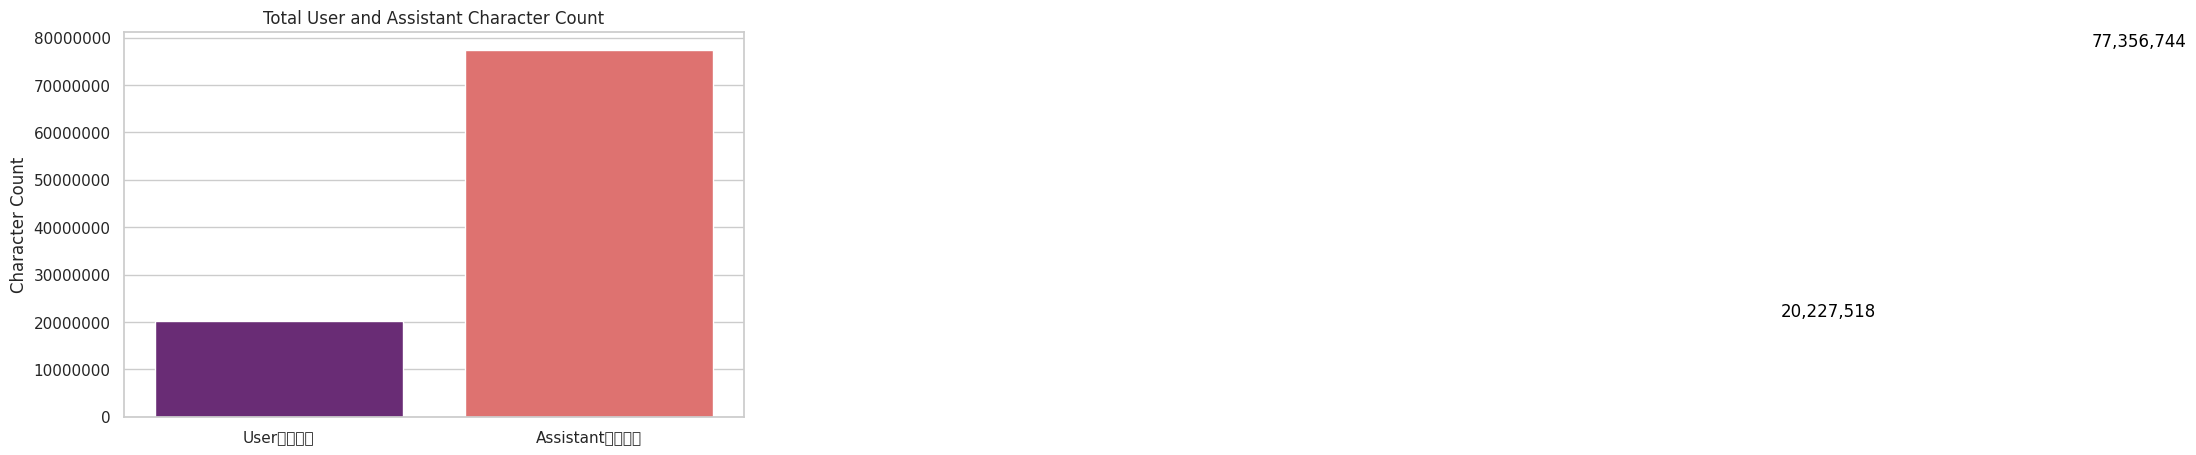

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

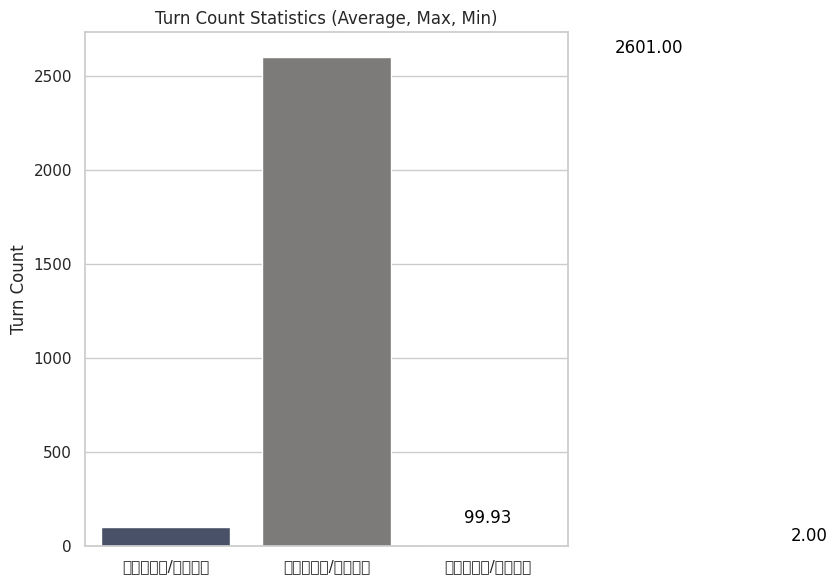

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


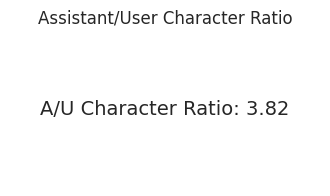

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

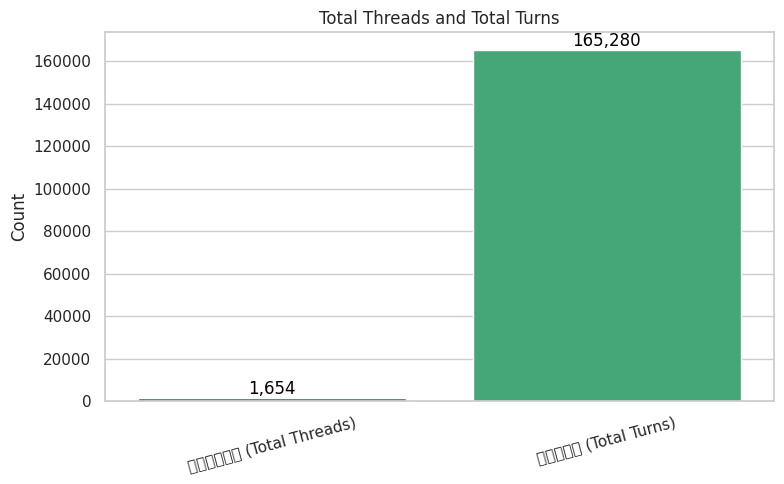

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

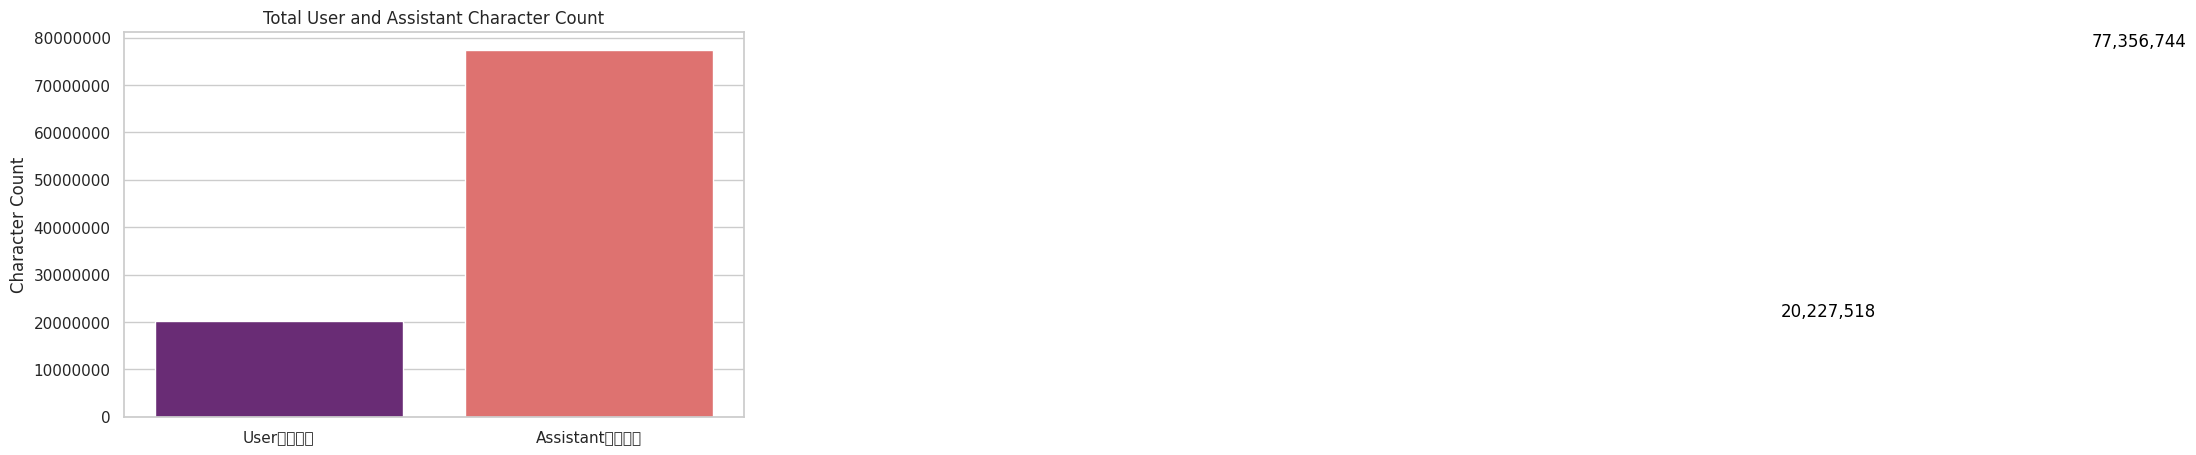

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

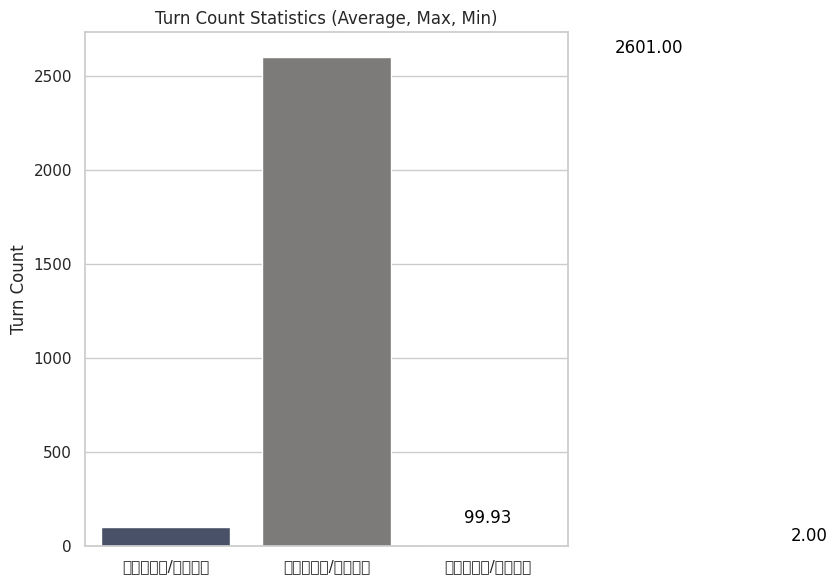

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


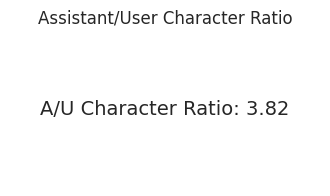

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

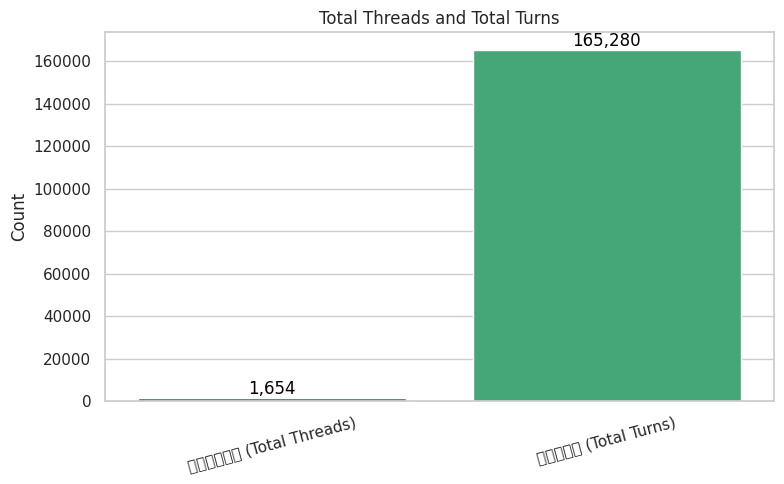

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

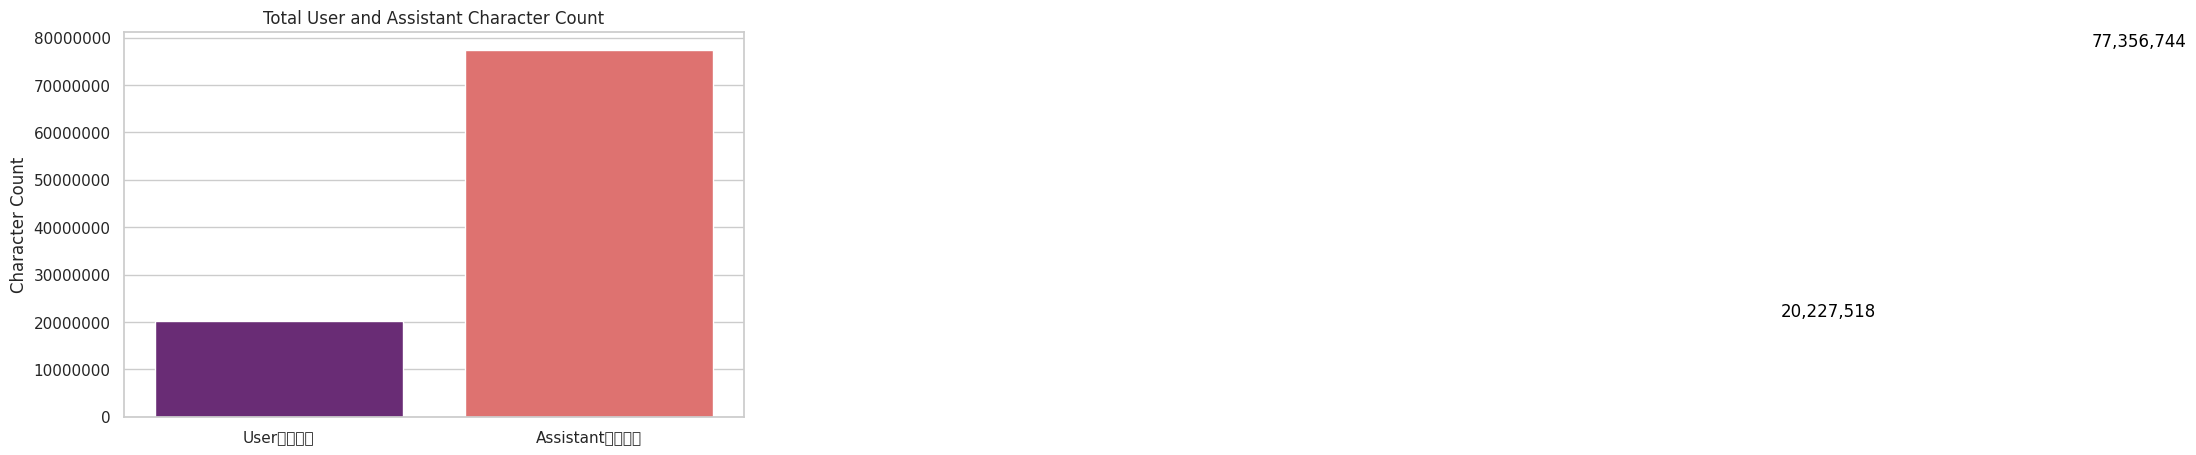

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

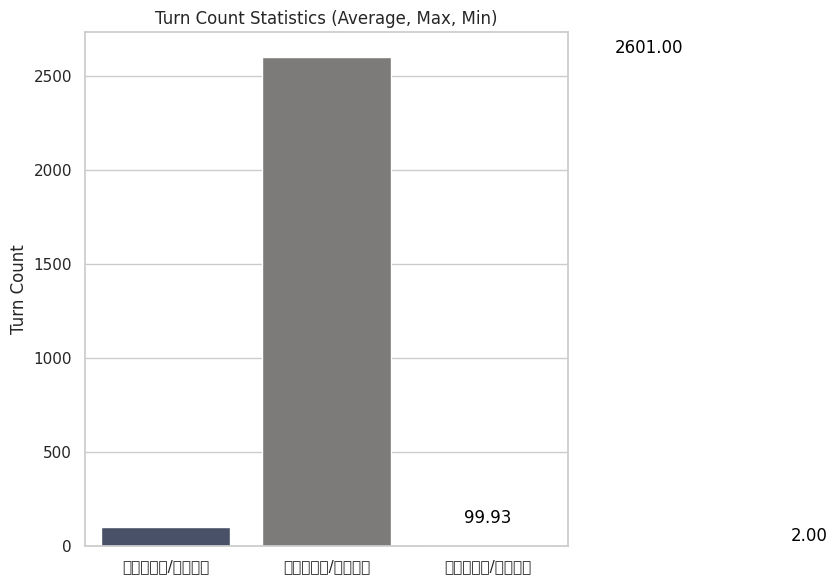

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


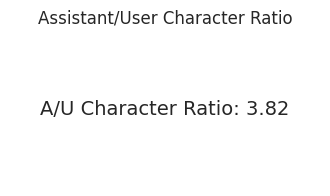

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

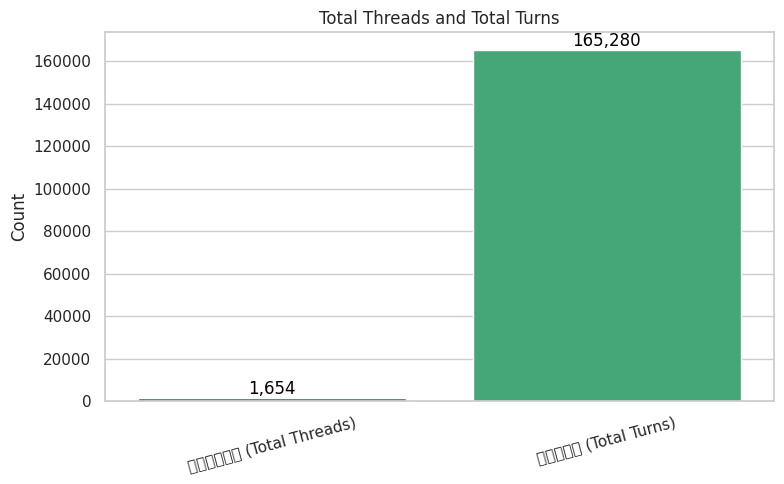

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

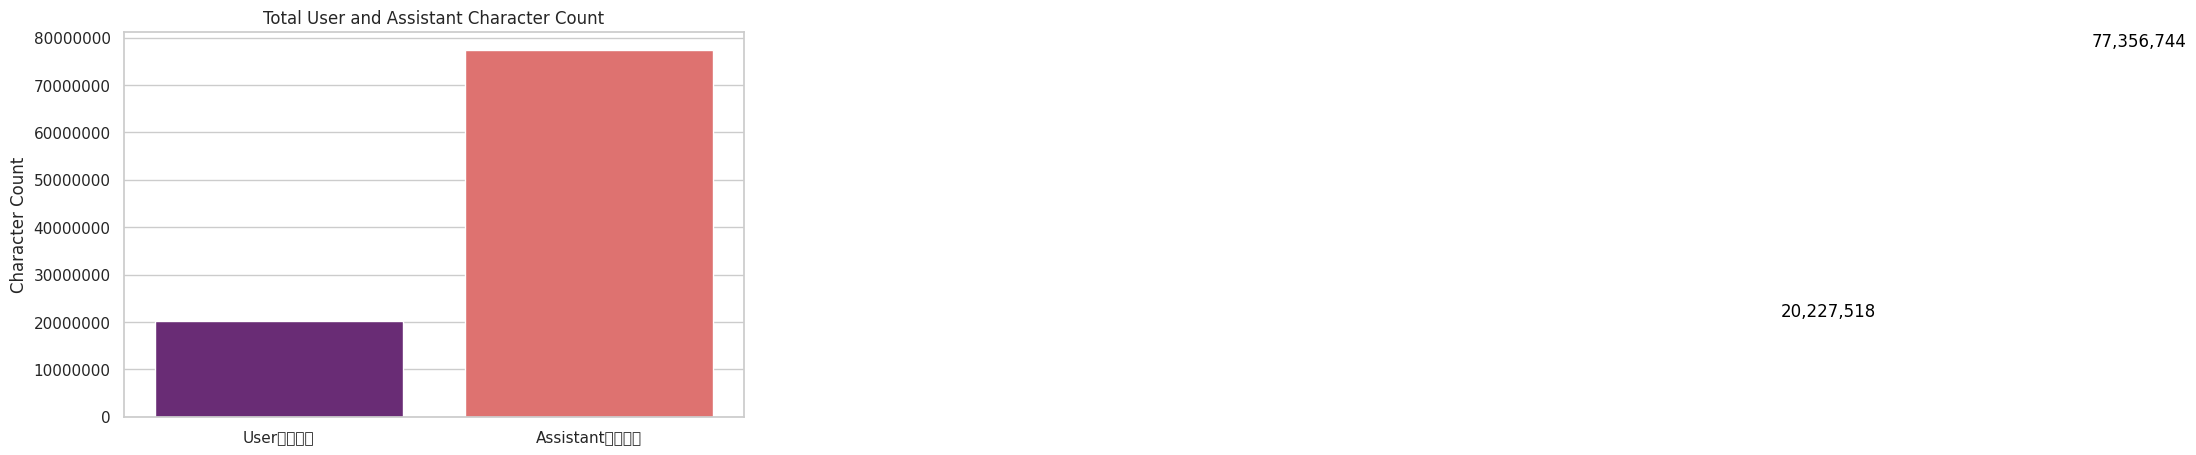

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

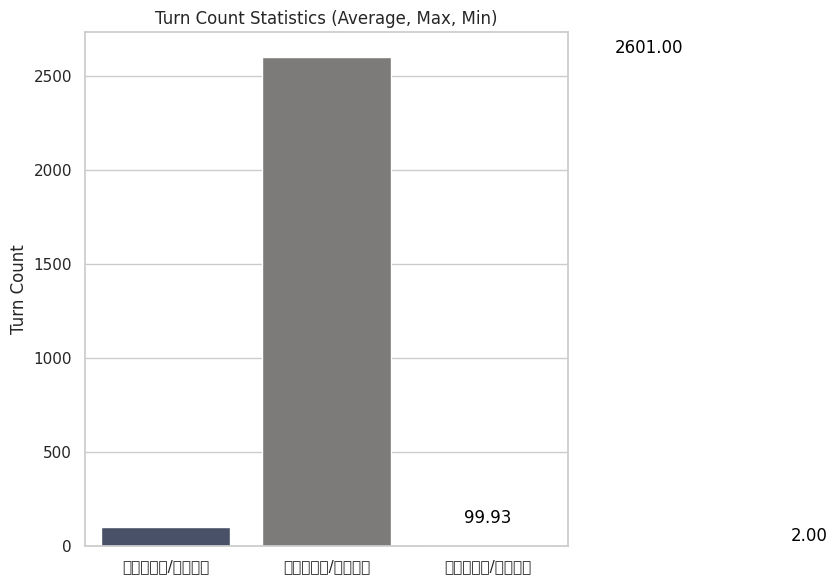

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


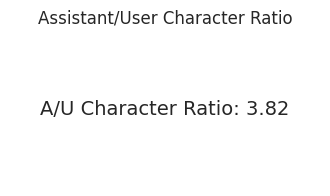

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

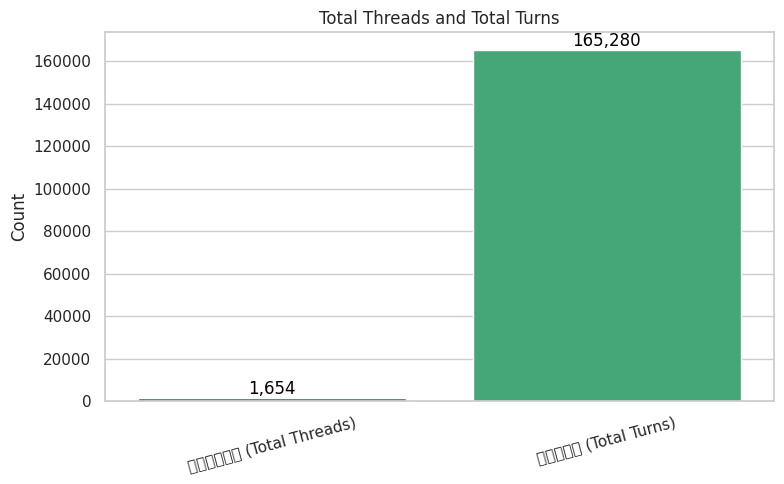

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

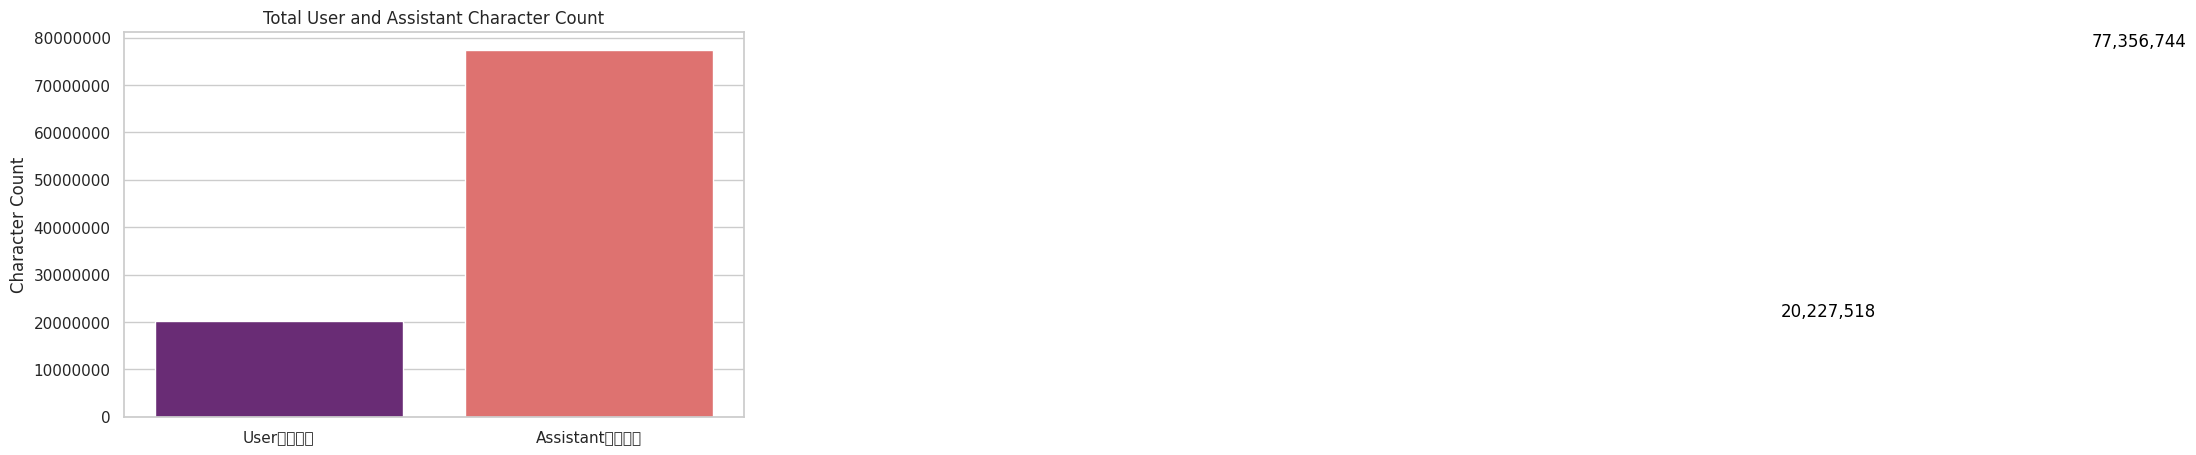

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

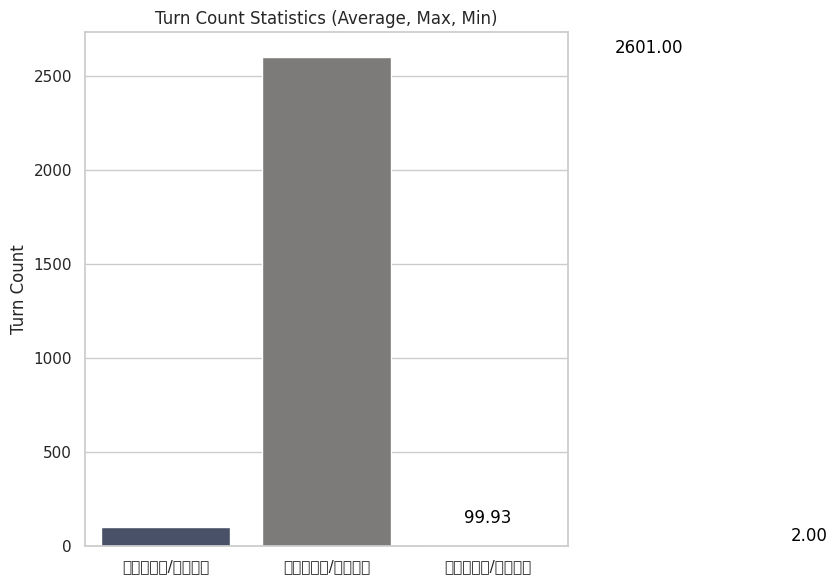

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


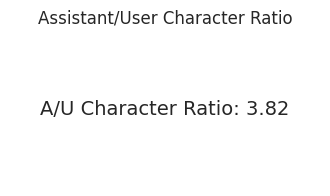

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

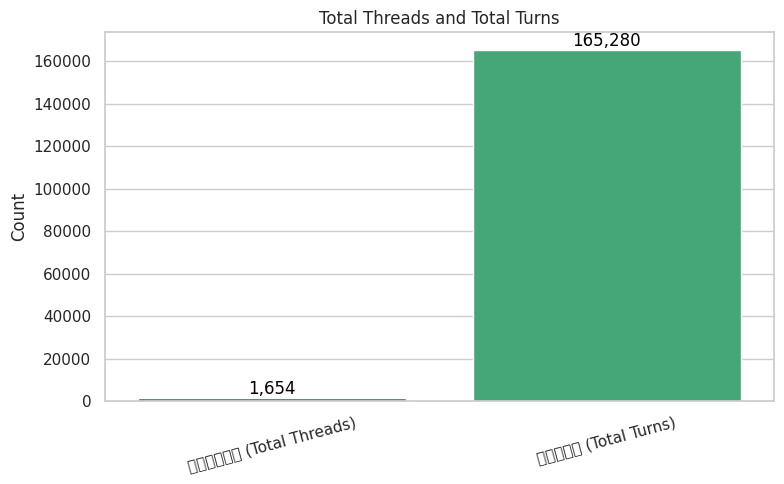

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

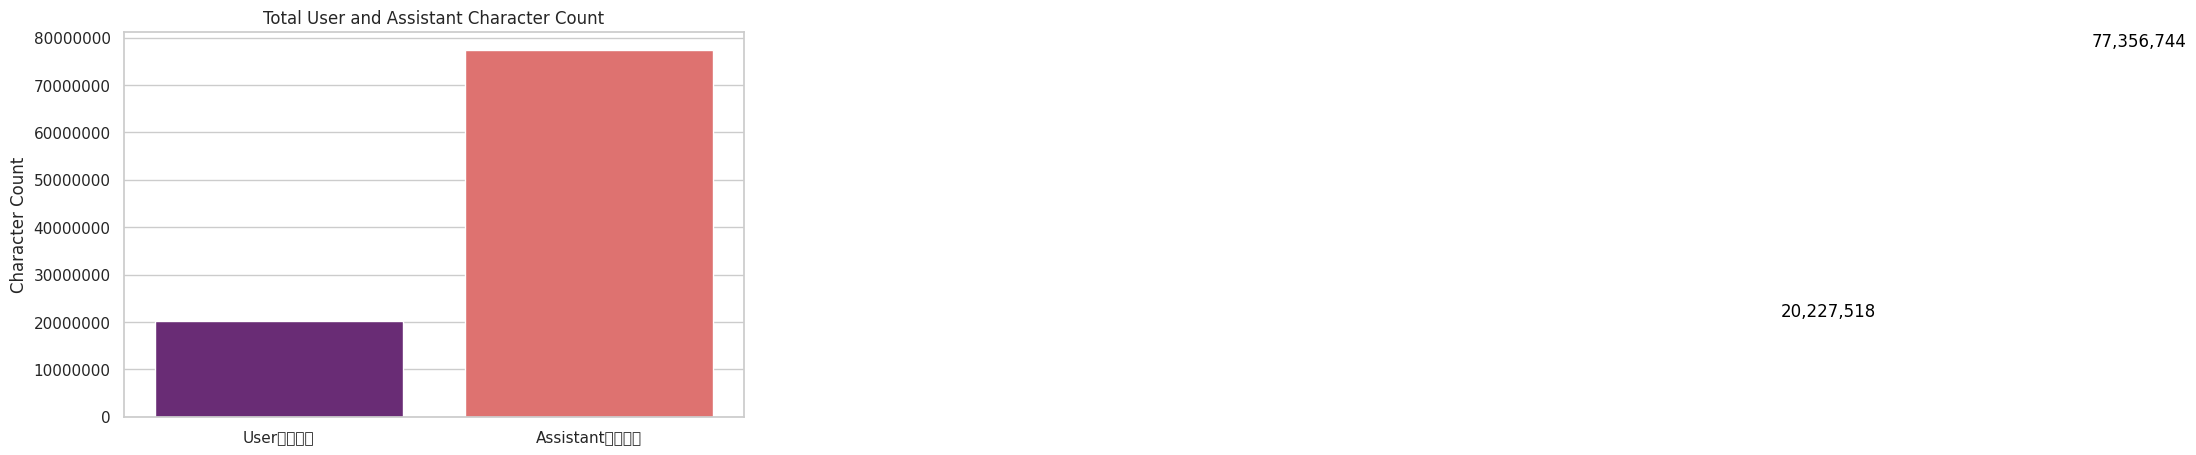

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

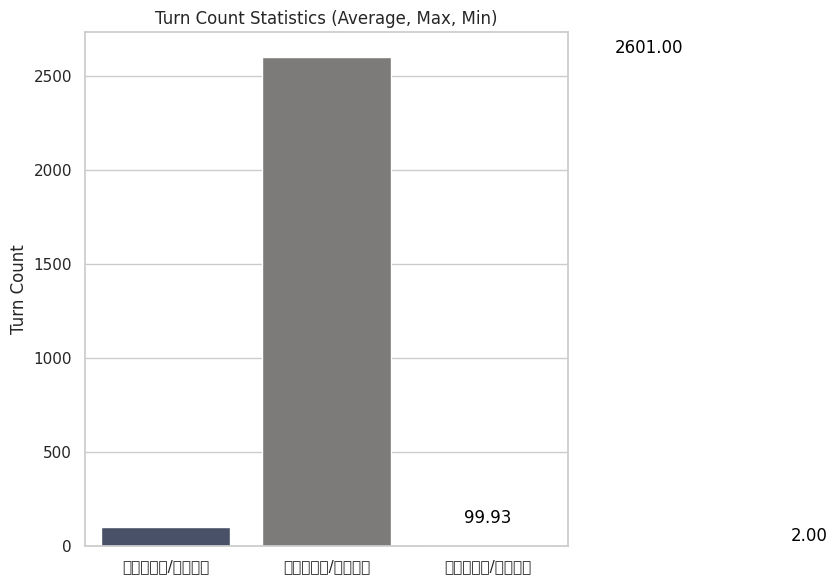

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


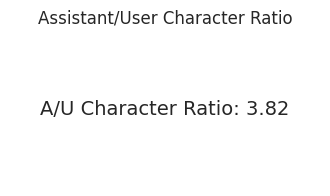

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

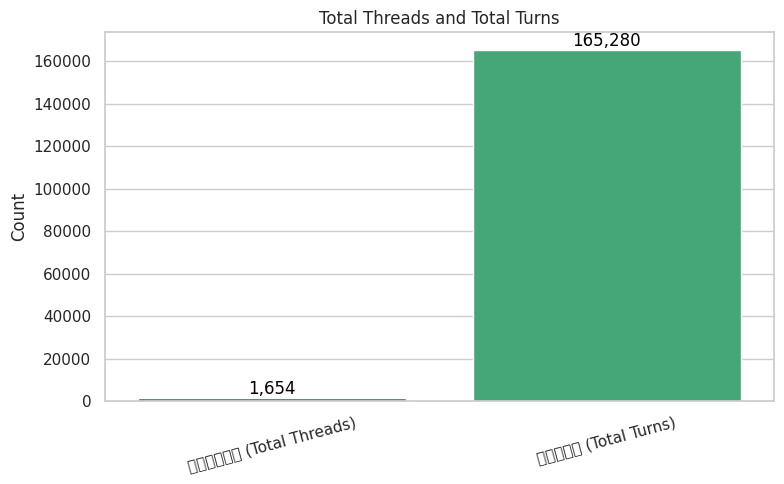

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

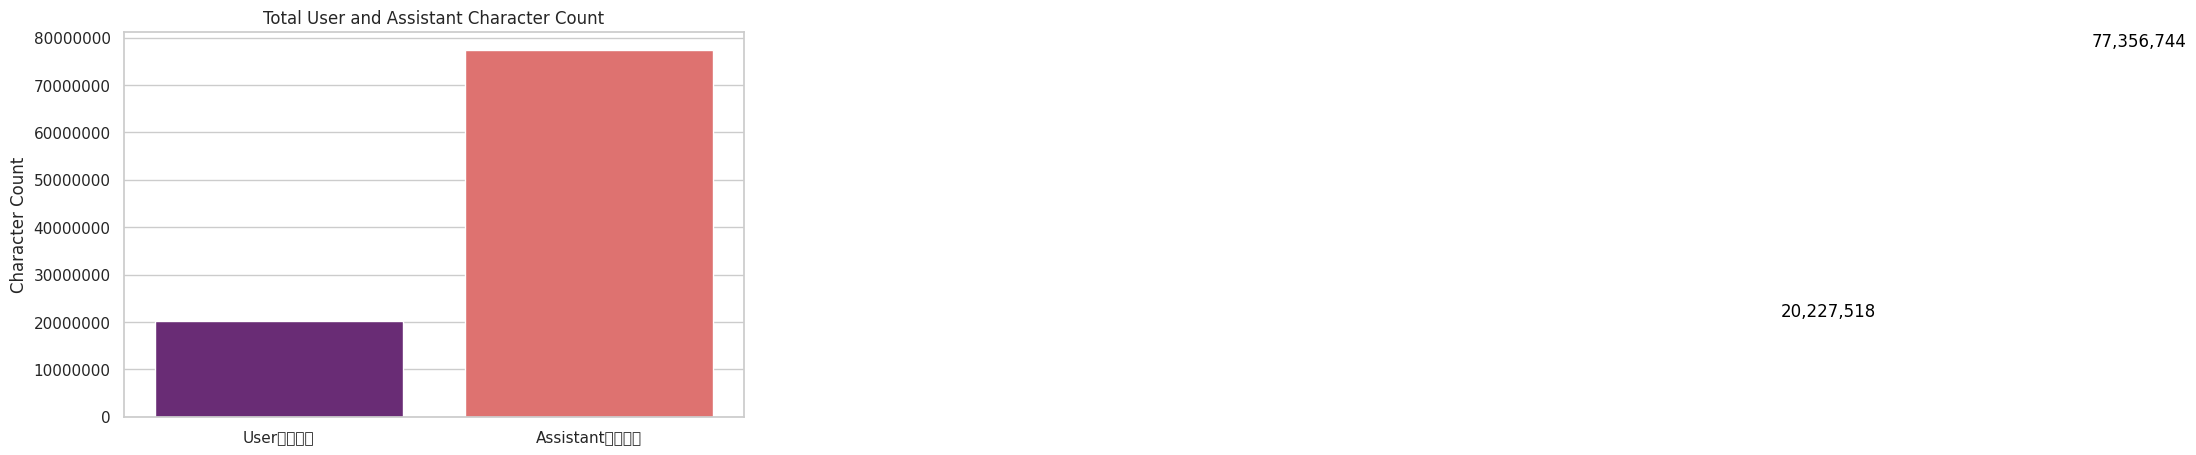

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

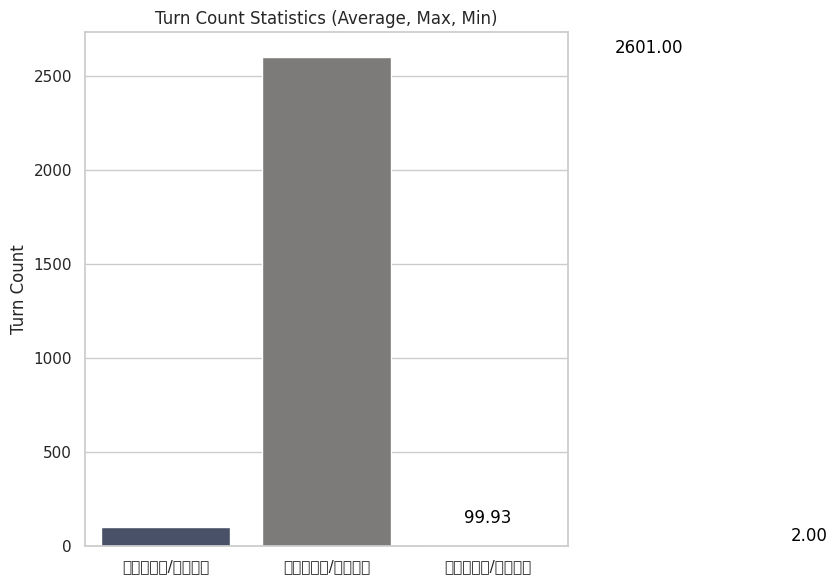

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


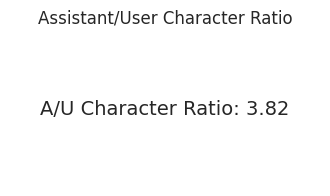

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

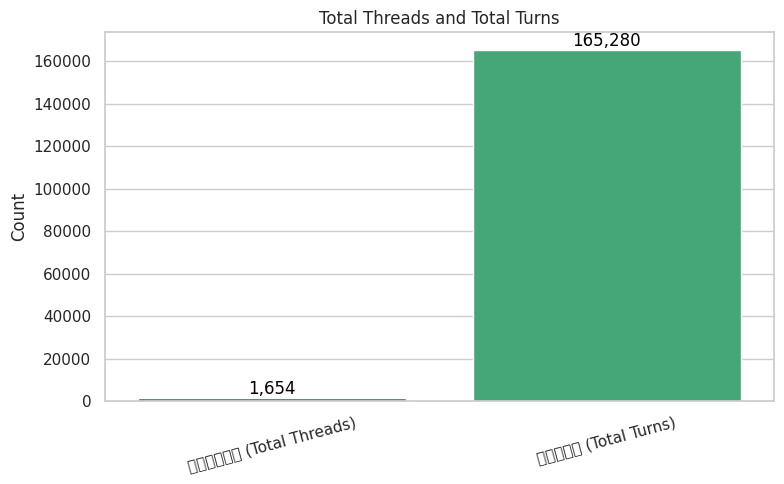

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

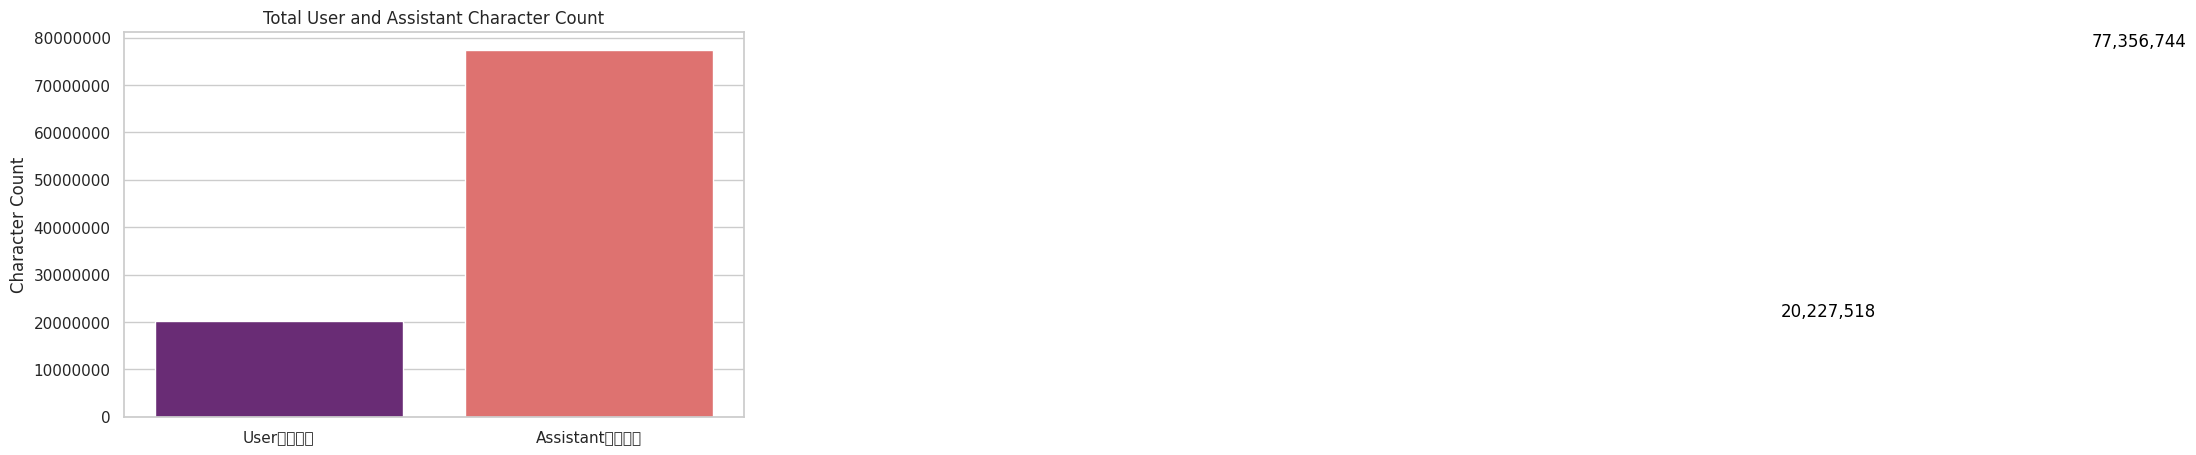

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

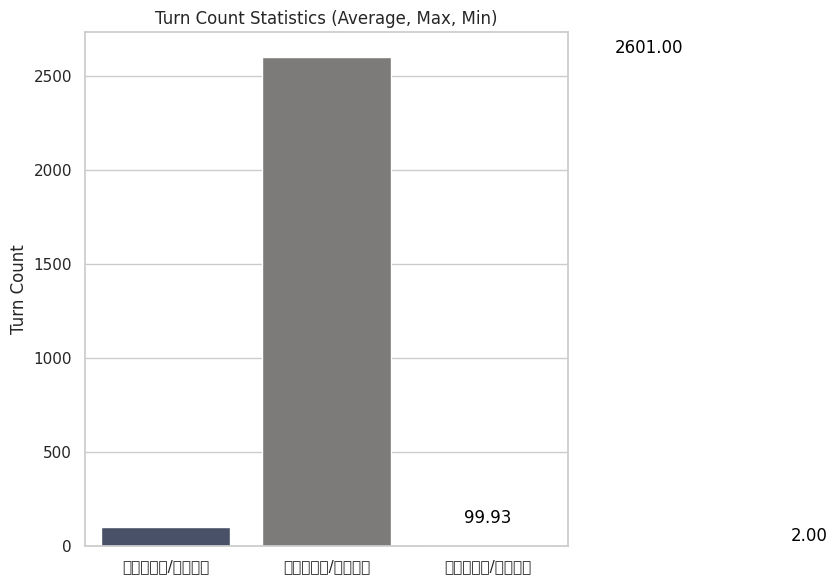

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


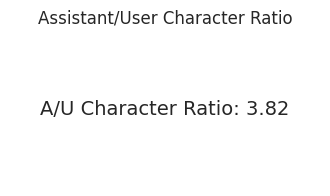

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

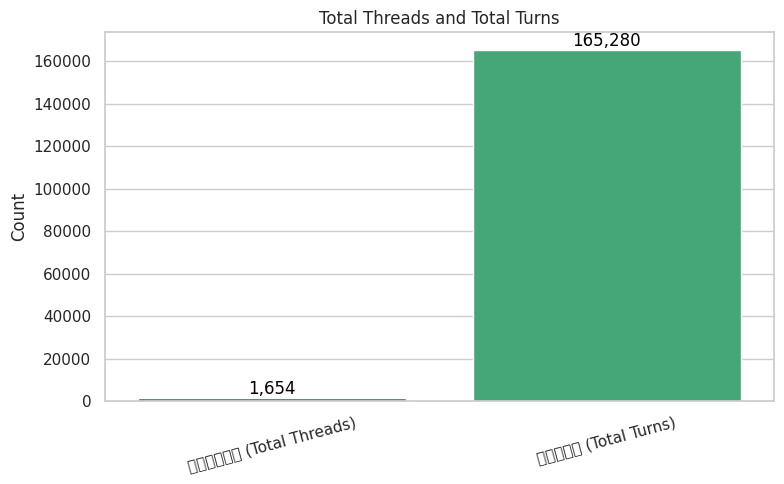

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

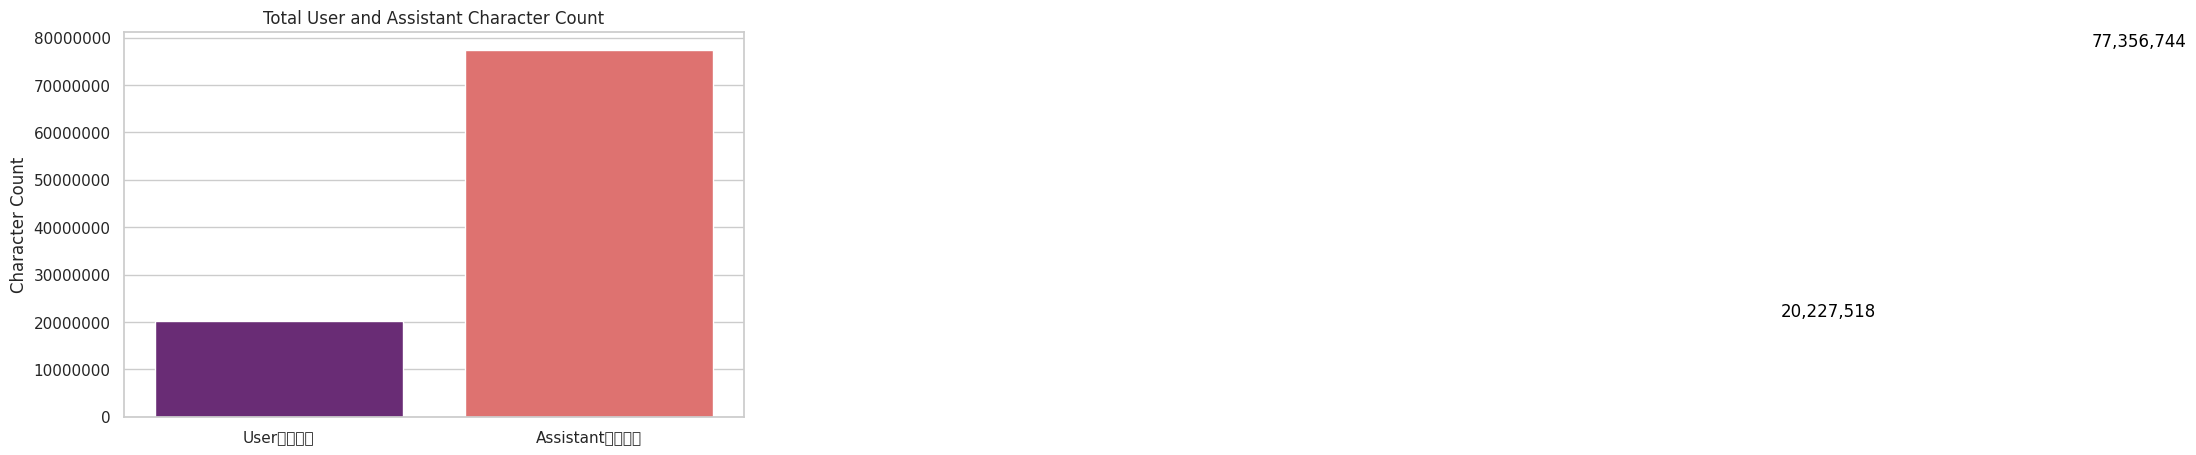

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

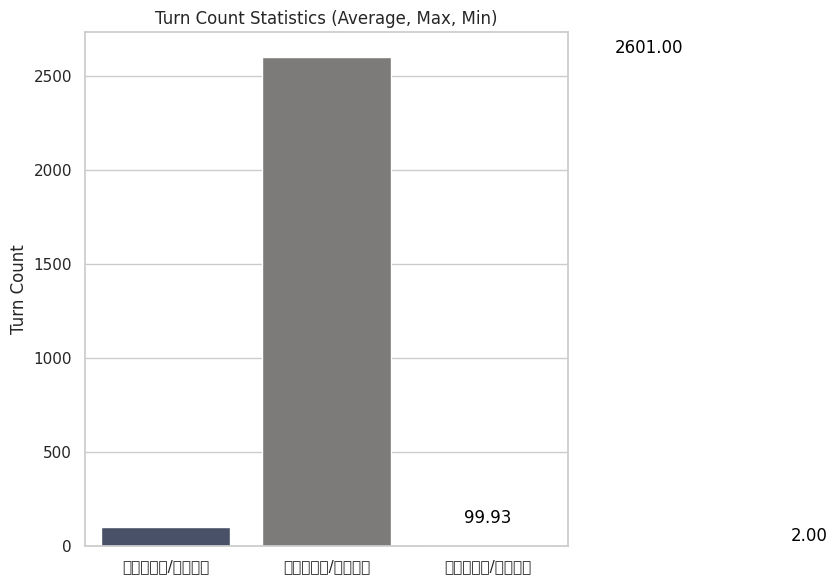

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


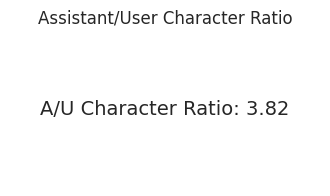

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

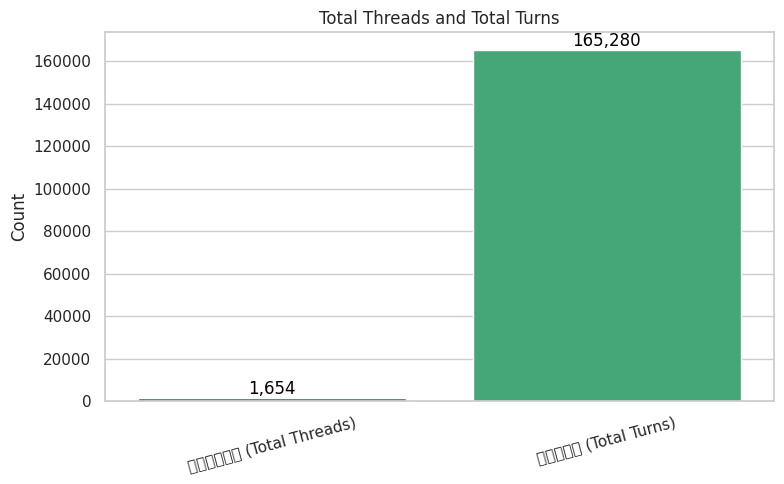

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

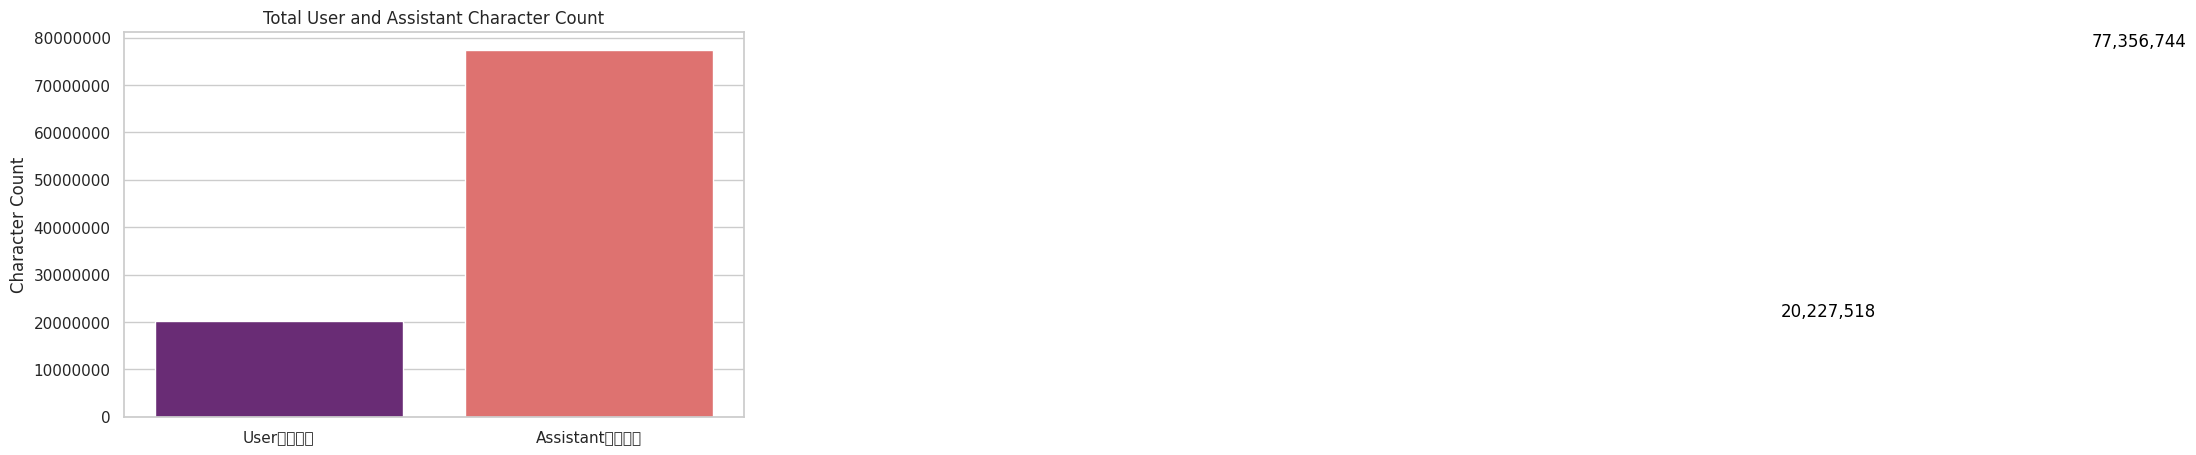

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

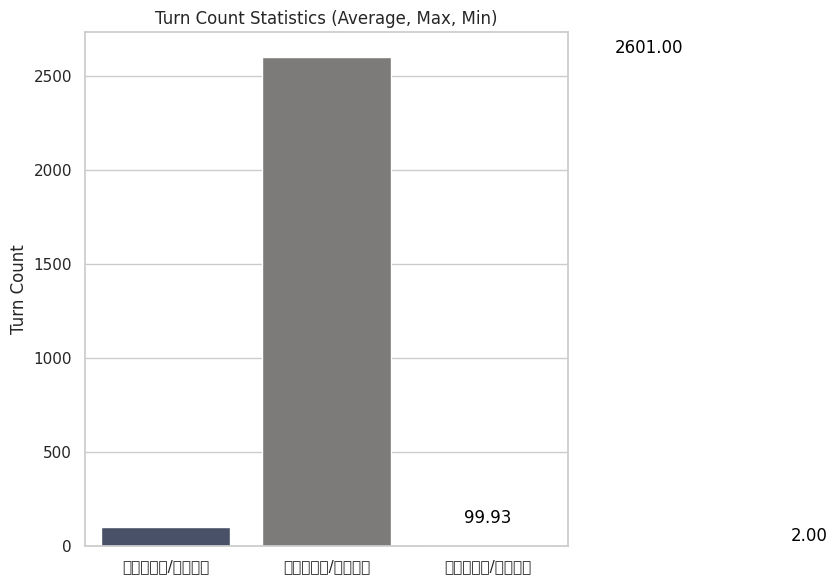

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


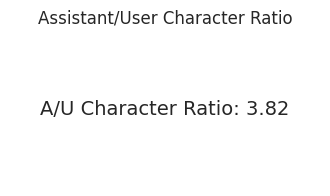

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

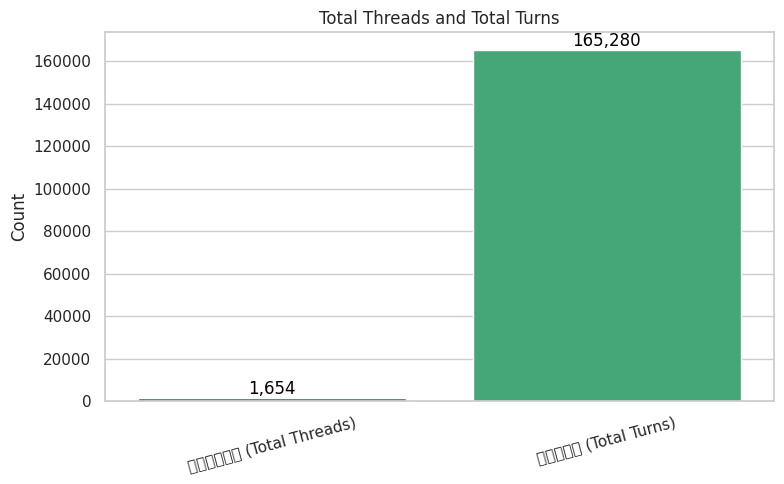

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

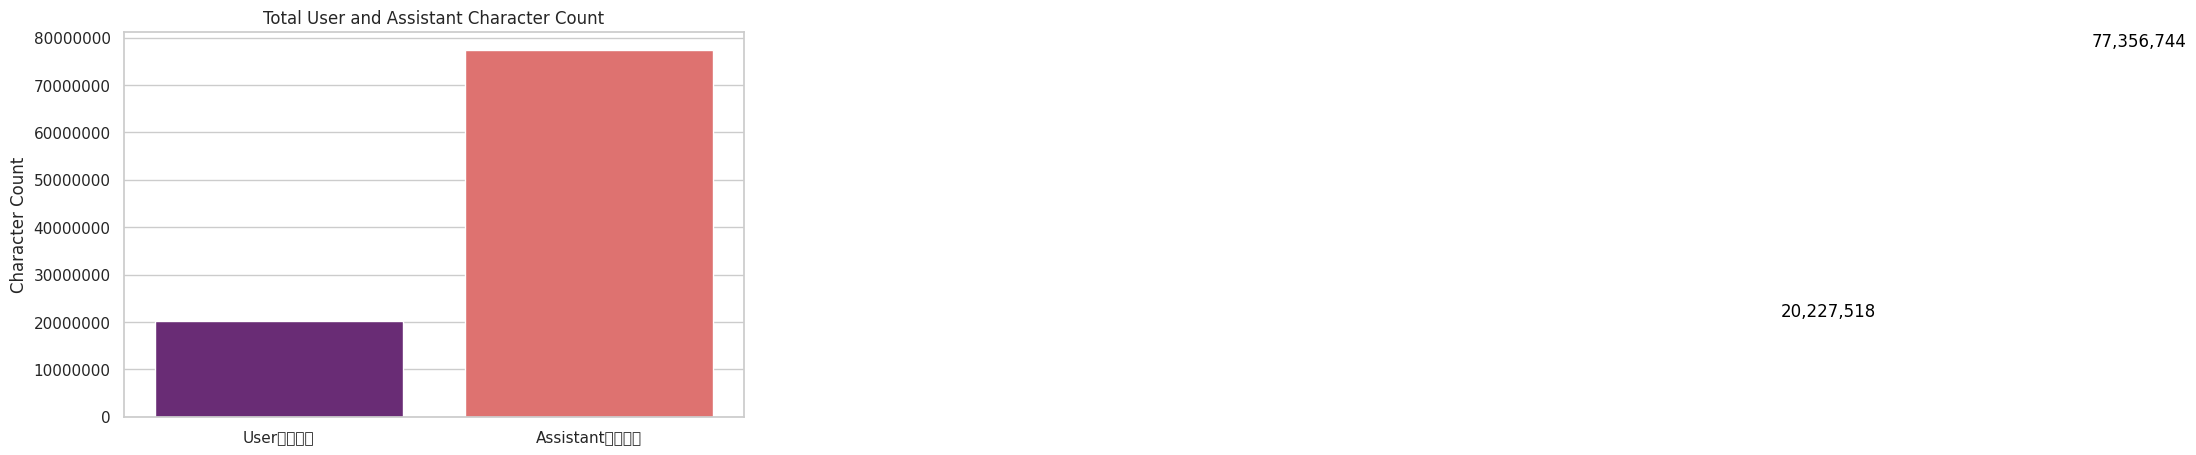

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

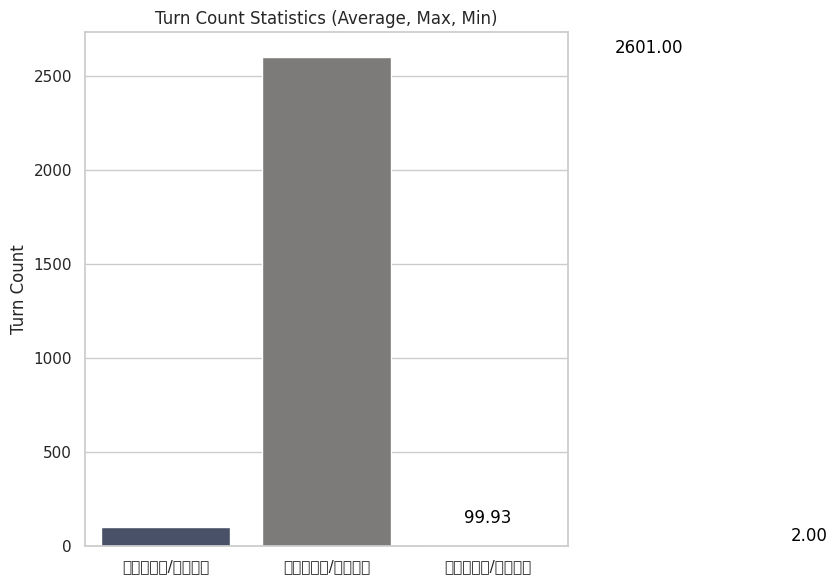

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


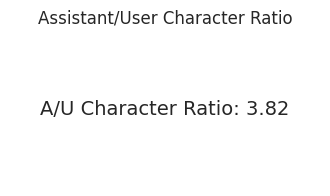

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

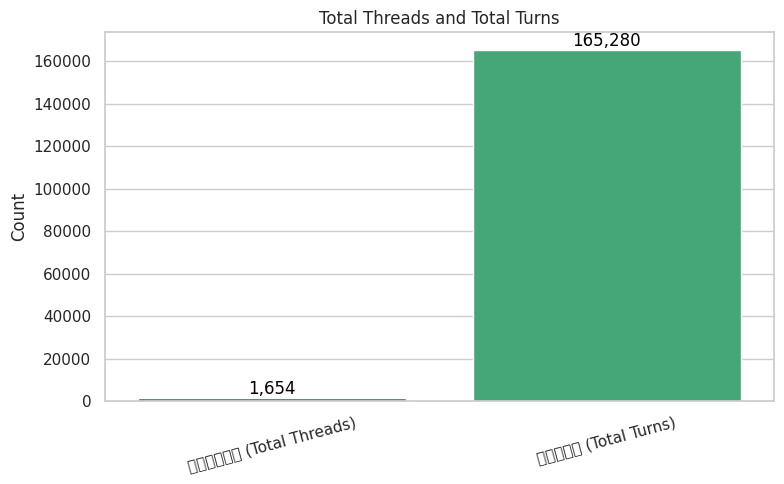

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

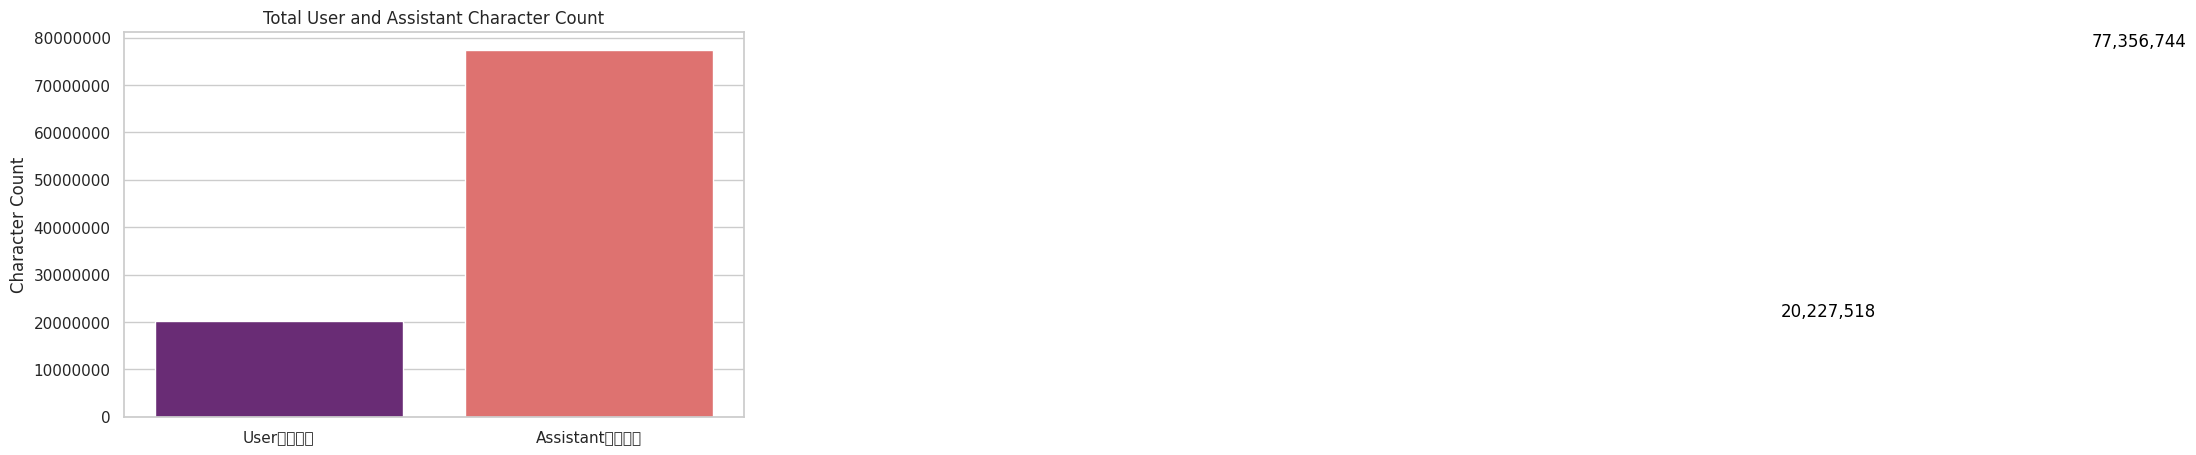

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

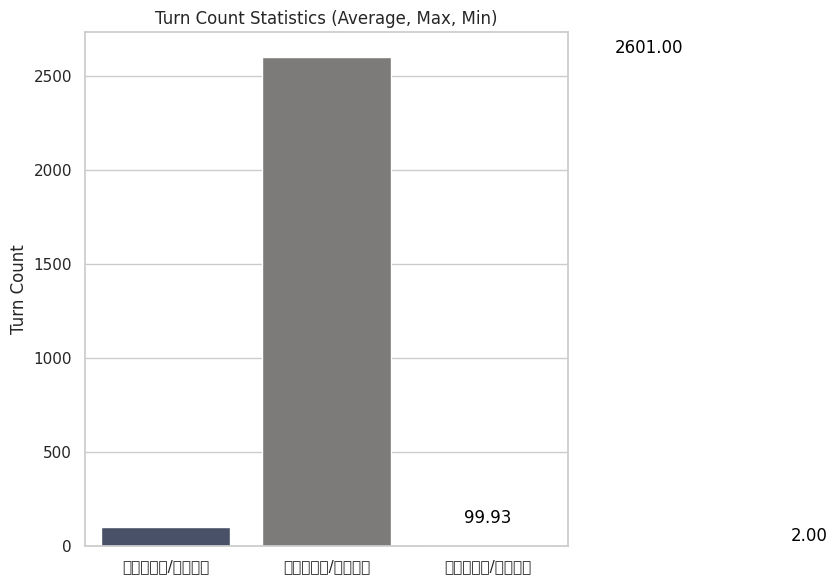

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


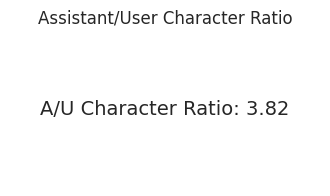

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

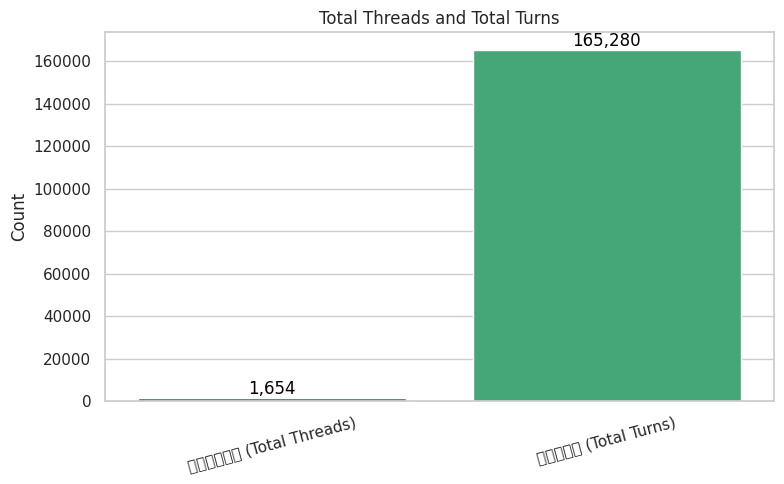

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

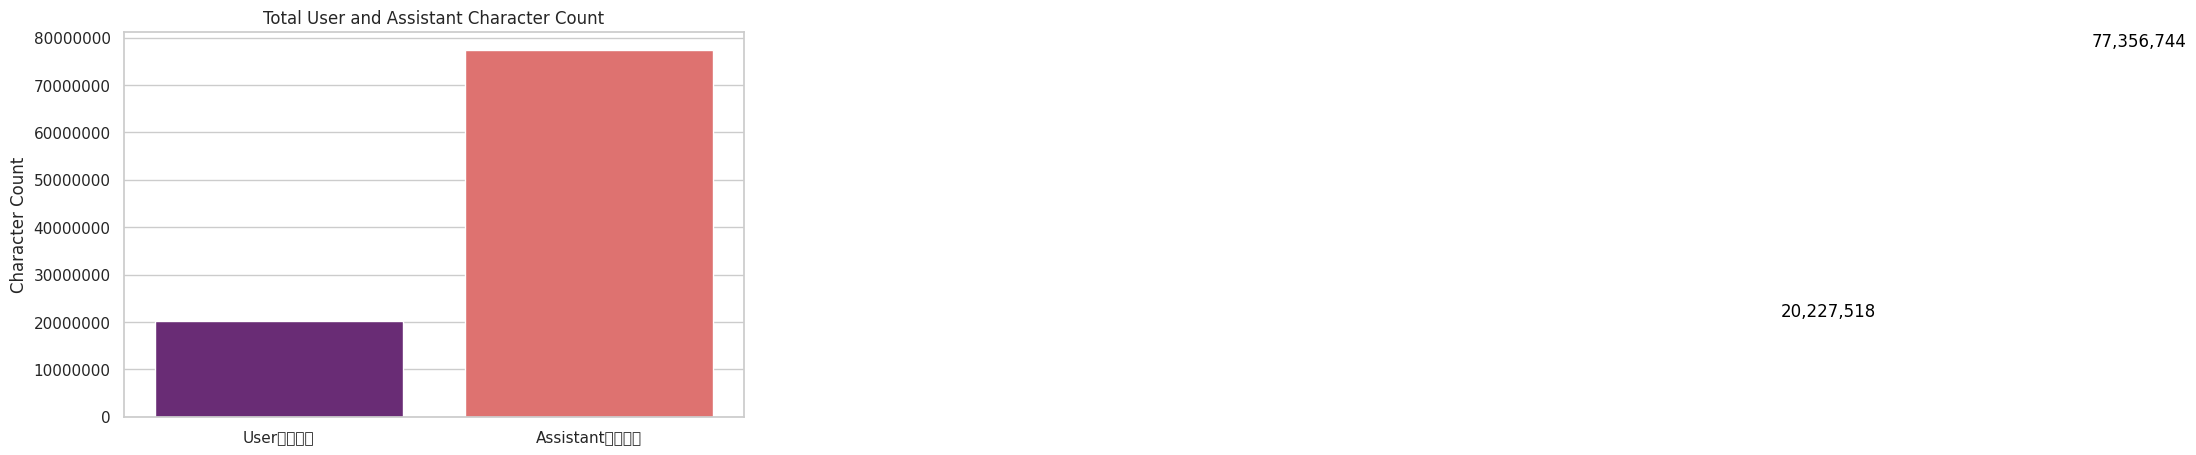

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

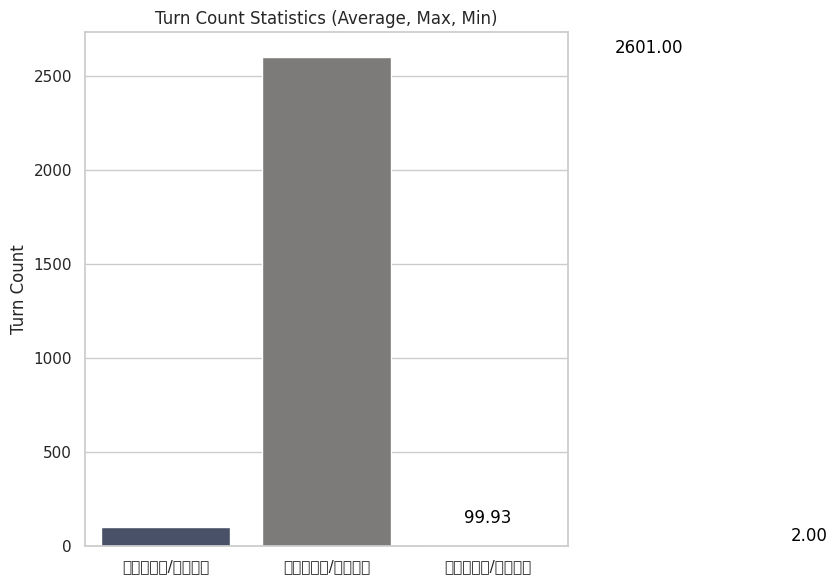

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


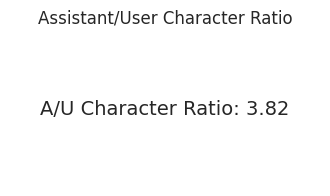

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

In [4]:
import pandas as pd
import os

# 統計情報を辞書として準備
stats_data = {
    '統計項目': [
        '総スレッド数 (Total Threads)',
        '総ターン数 (Total Turns)',
        '平均ターン/スレッド',
        '最大ターン/スレッド',
        '最小ターン/スレッド',
        'User総文字数',
        'Assistant総文字数',
        'A/U 文字数比率'
    ],
    '値': [
        total_threads,
        sum(turn_counts), # turn_counts variable is available
        f'{avg_turns:.2f}',
        max_turns,
        min_turns,
        user_chars_total,
        assistant_chars_total,
        f'{assistant_chars_total / user_chars_total:.2f}' if user_chars_total > 0 else 'N/A'
    ]
}

# DataFrameを作成
stats_df = pd.DataFrame(stats_data)

# 出力パスの設定
output_dir = '/content/drive/MyDrive/cooking_note/'
output_filename = 'sft_corpus_stats.csv'
output_path = os.path.join(output_dir, output_filename)

# ディレクトリが存在しない場合は作成
os.makedirs(output_dir, exist_ok=True)

# CSVとして保存
stats_df.to_csv(output_path, index=False, encoding='utf-8')

print(f"統計情報を '{output_path}' に保存しました。")

統計情報を '/content/drive/MyDrive/cooking_note/sft_corpus_stats.csv' に保存しました。


In [5]:
import pandas as pd
display(stats_df.head())

,統計項目,値
0,総スレッド数 (Total Threads),1654
1,総ターン数 (Total Turns),165280
2,平均ターン/スレッド,99.93
3,最大ターン/スレッド,2601
4,最小ターン/スレッド,2


/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

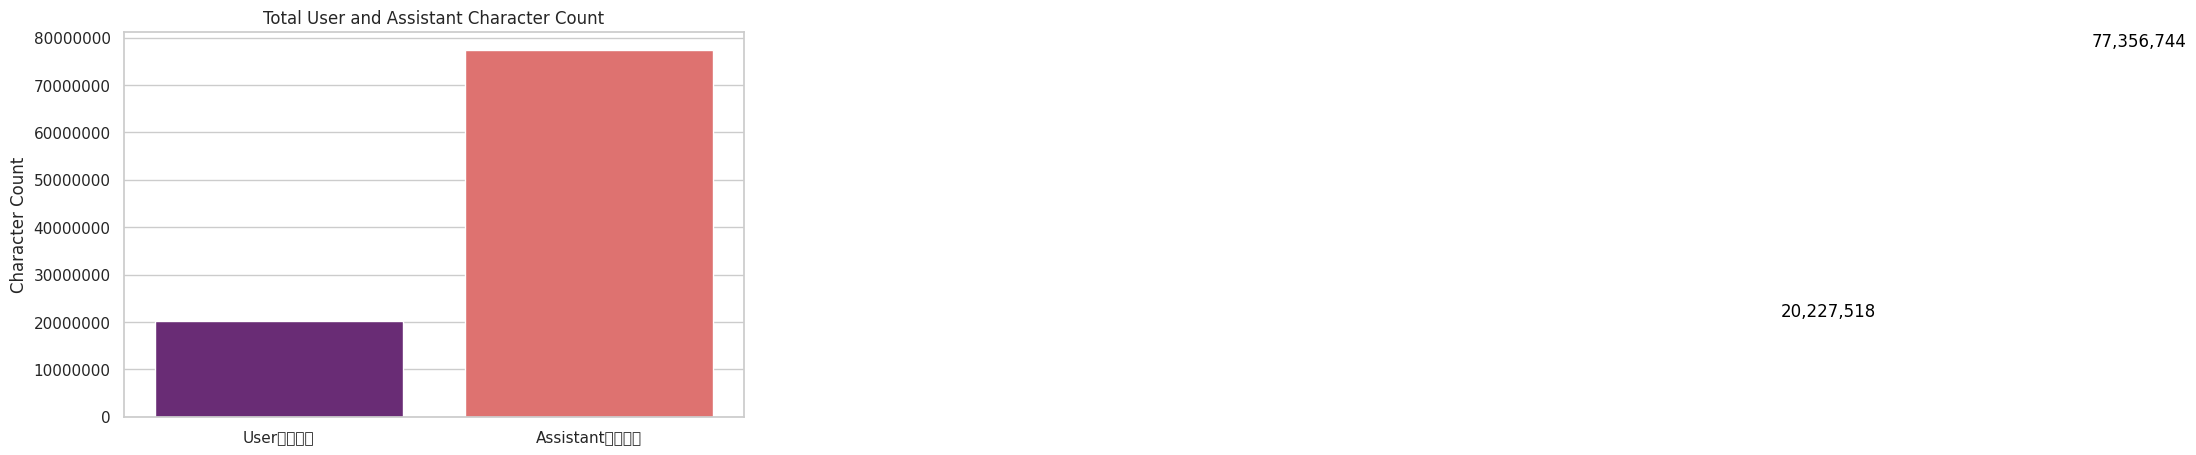

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

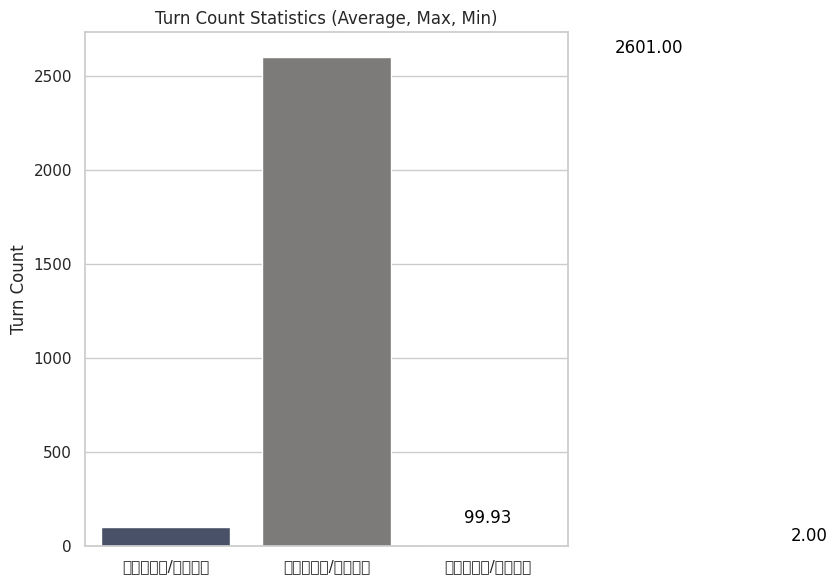

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


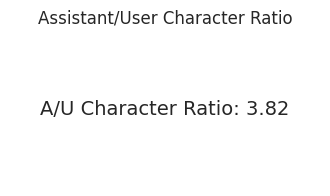

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

In [ ]:
# 日本語フォントの設定
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Colabに日本語フォントをインストール
!apt-get -y install fonts-ipafont-gothic
!rm -rf /root/.cache/matplotlib # フォントキャッシュを完全に削除

# フォントキャッシュをクリアし、再構築
plt.rcParams['font.family'] = "IPA Gothic"
plt.rcParams['axes.unicode_minus'] = False # マイナス記号を正しく表示

print("日本語フォント設定を完了しました。ランタイムを再起動してください。")

/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3594167654.py:20: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans

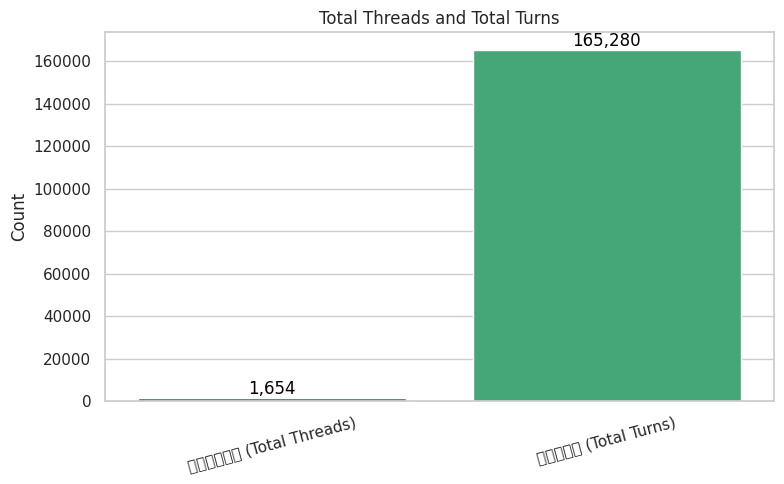

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total Threads and Total Turns')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/395940492.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

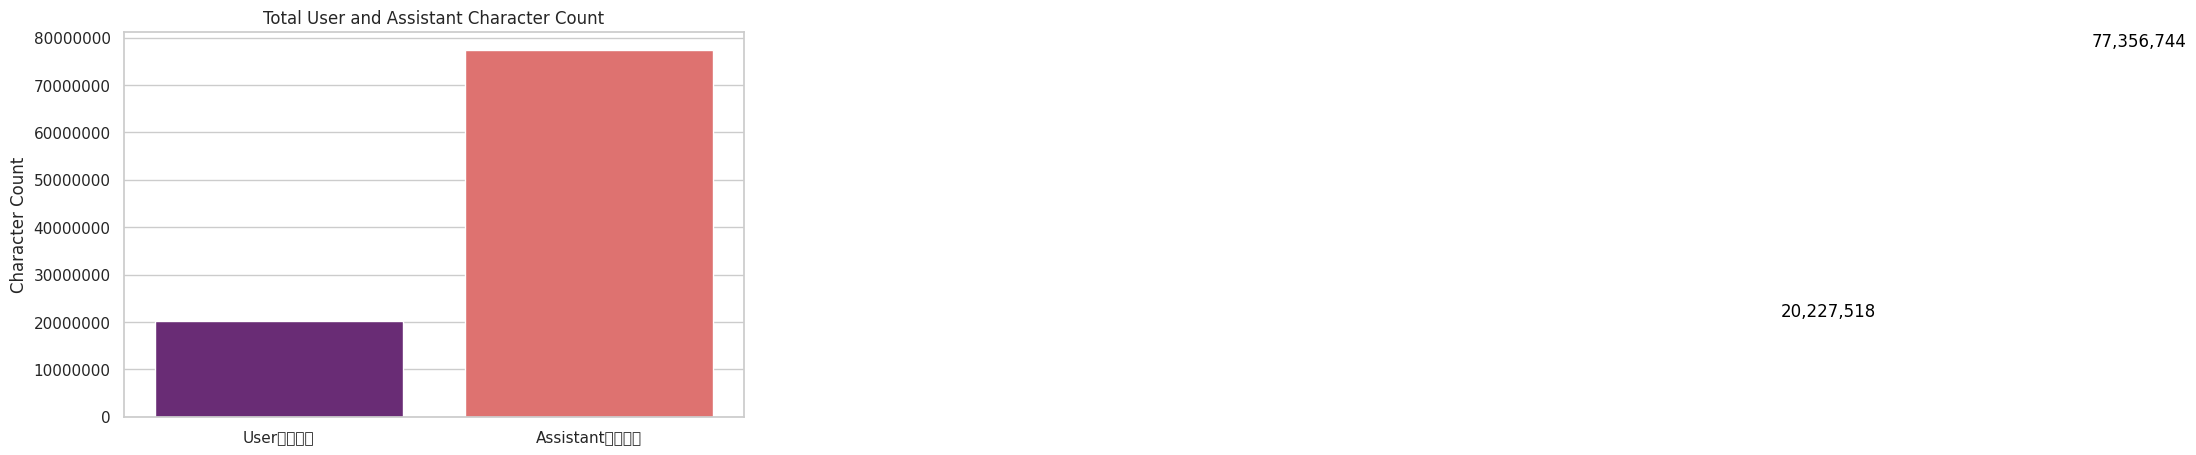

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Total User and Assistant Character Count')
plt.ylabel('Character Count')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3335282574.py:18: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s

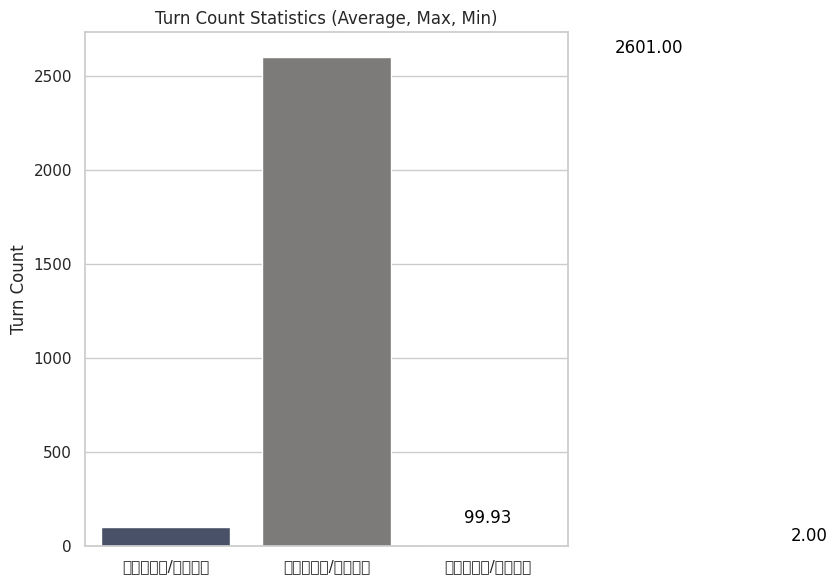

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('Turn Count Statistics (Average, Max, Min)')
plt.ylabel('Turn Count')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

A/U Character Ratio: 3.82


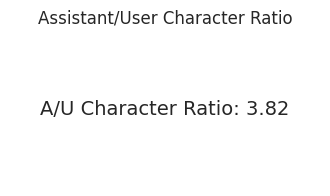

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U Character Ratio: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U Character Ratio: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User Character Ratio')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.font_manager as fm

sns.set_theme(style="whitegrid")

# 日本語フォントの設定
# Colabに日本語フォントをインストール
!apt-get -y install fonts-ipafont-gothic
!rm -rf /root/.cache/matplotlib # キャッシュを完全に削除

# フォントキャッシュをクリアし、再構築
plt.rcParams['font.family'] = "IPA Gothic"
plt.rcParams['axes.unicode_minus'] = False # マイナス記号を正しく表示

# 1. 総スレッド数と総ターン数の可視化
threads_turns_df = stats_df[stats_df['統計項目'].isin(['総スレッド数 (Total Threads)', '総ターン数 (Total Turns)'])].copy()
threads_turns_df['値'] = pd.to_numeric(threads_turns_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=threads_turns_df, palette='viridis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('総スレッド数と総ターン数')
plt.ylabel('数')
plt.xlabel('')
plt.xticks(rotation=15)
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in threads_turns_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import matplotlib.font_manager as fm # フォント設定は最初のセルで一括して行います

sns.set_theme(style="whitegrid")

# フォントキャッシュをクリアし、再構築 (最初のセルで実行済み)
# plt.rcParams['font.family'] = "IPA Gothic" # 最初のセルで設定済み
# plt.rcParams['axes.unicode_minus'] = False # 最初のセルで設定済み

# 2. User総文字数とAssistant総文字数の可視化
chars_df = stats_df[stats_df['統計項目'].isin(['User総文字数', 'Assistant総文字数'])].copy()
chars_df['値'] = pd.to_numeric(chars_df['値'])

plt.figure(figsize=(8, 5))
sns.barplot(x='統計項目', y='値', data=chars_df, palette='magma', hue='統計項目', legend=False) # FutureWarning対応
plt.title('User総文字数とAssistant総文字数')
plt.ylabel('文字数')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # y軸の表記を通常の数字にする
for index, row in chars_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:,}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import matplotlib.font_manager as fm # フォント設定は最初のセルで一括して行います

sns.set_theme(style="whitegrid")

# フォントキャッシュをクリアし、再構築 (最初のセルで実行済み)
# plt.rcParams['font.family'] = "IPA Gothic" # 最初のセルで設定済み
# plt.rcParams['axes.unicode_minus'] = False # 最初のセルで設定済み

# 3. 平均、最大、最小ターン数の可視化
turn_stats_df = stats_df[stats_df['統計項目'].isin(['平均ターン/スレッド', '最大ターン/スレッド', '最小ターン/スレッド'])].copy()
turn_stats_df['値'] = pd.to_numeric(turn_stats_df['値'])

plt.figure(figsize=(10, 6))
sns.barplot(x='統計項目', y='値', data=turn_stats_df, palette='cividis', hue='統計項目', legend=False) # FutureWarning対応
plt.title('ターン数統計 (平均、最大、最小)')
plt.ylabel('ターン数')
plt.xlabel('')
for index, row in turn_stats_df.iterrows():
    plt.text(index, row['値'], f'{row['値']:.2f}', color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import matplotlib.font_manager as fm # フォント設定は最初のセルで一括して行います

sns.set_theme(style="whitegrid")

# フォントキャッシュをクリアし、再構築 (最初のセルで実行済み)
# plt.rcParams['font.family'] = "IPA Gothic" # 最初のセルで設定済み
# plt.rcParams['axes.unicode_minus'] = False # 最初のセルで設定済み

# 4. A/U 文字数比率の可視化 (単一値のためテキストで表示)
ratio_df = stats_df[stats_df['統計項目'] == 'A/U 文字数比率'].copy()
ratio_value = ratio_df['値'].iloc[0]

print(f"A/U 文字数比率: {ratio_value}")

# 必要であれば、matplotlibでテキストとして表示
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"A/U 文字数比率: {ratio_value}", fontsize=14, ha='center', va='center')
plt.axis('off')
plt.title('Assistant/User 文字数比率')
plt.show()

In [ ]:
import pandas as pd
import os

# 統計情報を辞書として準備
stats_data = {
    '統計項目': [
        '総スレッド数 (Total Threads)',
        '総ターン数 (Total Turns)',
        '平均ターン/スレッド',
        '最大ターン/スレッド',
        '最小ターン/スレッド',
        'User総文字数',
        'Assistant総文字数',
        'A/U 文字数比率'
    ],
    '値': [
        total_threads,
        sum(turn_counts), # turn_counts variable is available
        f'{avg_turns:.2f}',
        max_turns,
        min_turns,
        user_chars_total,
        assistant_chars_total,
        f'{assistant_chars_total / user_chars_total:.2f}' if user_chars_total > 0 else 'N/A'
    ]
}

# DataFrameを作成
stats_df = pd.DataFrame(stats_data)

# 出力パスの設定
output_dir = '/content/drive/MyDrive/cooking_note/'
output_filename = 'sft_corpus_stats.csv'
output_path = os.path.join(output_dir, output_filename)

# ディレクトリが存在しない場合は作成
os.makedirs(output_dir, exist_ok=True)

# CSVとして保存
stats_df.to_csv(output_path, index=False, encoding='utf-8')

print(f"統計情報を '{output_path}' に保存しました。")